# Dynamic Exploratory Data Analysis (EDA) - Superstore Sales Dataset
Welcome to this comprehensive Exploratory Data Analysis (EDA) of the cleaned Superstore Sales dataset. This analysis is structured for a professional Data Analytics portfolio and aims to uncover key trends, assess data quality, and identify business insights to optimize sales, profitability, shipping efficiency, and customer segments.

## Objectives:
1. **Dynamic Column Classification**: Inspect the dataset dynamically without hardcoding column names.
2. **Data Quality Assessment**: Check for missing values, duplicates, and check shipping logical consistency.
3. **Univariate Analysis**: Plot and analyze distributions of individual numerical and categorical columns.
4. **Bivariate Analysis**: Analyze relationships between numerical variables and compare numerical values across categorical dimensions.
5. **Multivariate Analysis**: Study correlations, pair plots, and multi-dimensional scatter relationships.
6. **Time Series Analysis**: Extract temporal trends, annual growth, and monthly seasonality.
7. **Numerical & Outlier Analysis**: Quantify skewness, kurtosis, and outliers using IQR, and recommend handling actions.
8. **Business Insights & Recommendations**: Generate 15+ meaningful business findings and actionable recommendations.

All visualizations are optimized with appropriate palettes, titles, labels, and percentage markings for a publication-quality look.


## Setup and Styling
We import the necessary libraries (Pandas, NumPy, Matplotlib, Seaborn) and configure high-quality visualization styles, ensuring a consistent and premium look throughout the notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 100


## Load Dataset and Dynamic Column Classification
We load the dataset `Superstore_Cleaned.csv`. To ensure flexibility and robustness, we do not hardcode any column names. We dynamically classify columns into **Numerical**, **Categorical**, **Datetime**, and **Identifier/High-Cardinality** categories based on statistical thresholds and metadata naming patterns.


In [2]:
# Load the cleaned dataset
df = pd.read_csv('Superstore_Cleaned.csv')

# Dynamic classification lists
numerical_cols = []
categorical_cols = []
datetime_cols = []
identifier_cols = []

# Classify columns dynamically
for col in df.columns:
    # 1. Datetime detection:
    is_dt = False
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        is_dt = True
    else:
        # Check if the name suggests a date and a sample can be parsed
        if 'date' in col.lower() or 'time' in col.lower():
            try:
                sample = df[col].dropna().head(100)
                pd.to_datetime(sample, errors='raise')
                is_dt = True
            except:
                pass
    
    if is_dt:
        datetime_cols.append(col)
        df[col] = pd.to_datetime(df[col])
        continue
        
    # 2. Numerical detection:
    if pd.api.types.is_numeric_dtype(df[col]):
        unique_ratio = df[col].nunique() / len(df)
        # Check if it is an ID (e.g. integer incrementing, or is a postal code)
        if 'id' in col.lower() or 'key' in col.lower() or col.lower() == 'row id' or 'postal' in col.lower() or 'zip' in col.lower() or unique_ratio > 0.99:
            identifier_cols.append(col)
        else:
            numerical_cols.append(col)
    else:
        # 3. Categorical and Identifier detection:
        unique_ratio = df[col].nunique() / len(df)
        if 'id' in col.lower() or 'key' in col.lower() or unique_ratio > 0.5:
            identifier_cols.append(col)
        else:
            categorical_cols.append(col)

print("Dynamic Classification Results:")
print("-" * 50)
print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Datetime Columns ({len(datetime_cols)}): {datetime_cols}")
print(f"Identifier/ID Columns ({len(identifier_cols)}): {identifier_cols}")


Dynamic Classification Results:
--------------------------------------------------
Numerical Columns (8): ['Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Quarter', 'Shipping Days']
Categorical Columns (11): ['Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Month Name']
Datetime Columns (2): ['Order Date', 'Ship Date']
Identifier/ID Columns (5): ['Row ID', 'Order ID', 'Customer ID', 'Postal Code', 'Product ID']


## 1. Dataset Overview
We print the first and last 5 rows, the shape of the dataset, data types, and descriptive statistics. This provides a baseline understanding of our data range and statistics.


In [3]:
print("--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- LAST 5 ROWS ---")
display(df.tail())

print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

print("\n--- DATASET DETAILS ---")
df.info()

print("\n--- NUMERICAL STATISTICAL SUMMARY ---")
display(df.describe())

if len(categorical_cols) > 0:
    print("\n--- CATEGORICAL SUMMARY ---")
    display(df.describe(include=['O']))


--- FIRST 5 ROWS ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,7



--- LAST 5 ROWS ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Shipping Days
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Ultra Door Pull Handle,25.248,3,0.2,4.1028,2014,1,January,1,2
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,2017,2,February,1,5
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,2017,2,February,1,5
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,2017,2,February,1,5
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,2017,5,May,2,5



Dataset Shape: 9994 rows, 26 columns

--- DATASET DETAILS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category 

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Shipping Days
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,2.882329,3.958175
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,1.000000,0.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,2.000000,3.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,3.000000,4.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,4.000000,5.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,4.000000,7.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.058086,1.747567



--- CATEGORICAL SUMMARY ---


,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Month Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850,12
top,CA-2017-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,November
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48,1471


## 2. Data Quality Assessment
We perform structured checks to verify the cleanliness and logical consistency of the dataset. This includes detecting missing values, finding duplicates, listing unique values for low-cardinality columns, and performing shipping date logical checks.


In [4]:
print("--- MISSING VALUES ---")
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing Count', ascending=False)
display(missing_df)

print("\n--- DUPLICATE RECORDS ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates} ({duplicates/len(df)*100:.2f}%)")

print("\n--- UNIQUE VALUES IN CATEGORICAL COLUMNS ---")
unique_counts = df[categorical_cols].nunique().sort_values(ascending=False)
display(pd.DataFrame({'Unique Count': unique_counts}))

print("\n--- DATA LOGICAL CONSISTENCY CHECKS ---")
# Check if any sales, quantity or shipping days are negative
negative_checks = {}
for col in ['Sales', 'Quantity', 'Shipping Days']:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        negative_checks[col] = f"{neg_count} negative values"
print("Value boundary check:", negative_checks)

# Check if Ship Date is before Order Date
if 'Order Date' in df.columns and 'Ship Date' in df.columns:
    date_anomaly = (df['Ship Date'] < df['Order Date']).sum()
    print(f"Date anomaly check (Ship Date < Order Date): {date_anomaly} records")


--- MISSING VALUES ---


,Missing Count,Percentage (%)
Row ID,0,0.0
Order ID,0,0.0
Quarter,0,0.0
Month Name,0,0.0
Month,0,0.0
Year,0,0.0
Profit,0,0.0
Discount,0,0.0
Quantity,0,0.0
Sales,0,0.0



--- DUPLICATE RECORDS ---
Number of duplicate records: 0 (0.00%)

--- UNIQUE VALUES IN CATEGORICAL COLUMNS ---


,Unique Count
Product Name,1850
Customer Name,793
City,531
State,49
Sub-Category,17
Month Name,12
Ship Mode,4
Region,4
Segment,3
Category,3



--- DATA LOGICAL CONSISTENCY CHECKS ---
Value boundary check: {'Sales': '0 negative values', 'Quantity': '0 negative values', 'Shipping Days': '0 negative values'}
Date anomaly check (Ship Date < Order Date): 0 records


## 3. Univariate Analysis: Numerical Columns
We automatically generate distribution and boxplots for each numerical feature. For each numerical variable, we inspect:
- **Histogram with KDE (Kernel Density Estimate)**: To observe shape, symmetry, and peaks.
- **Boxplot**: To highlight the dispersion, quartiles, and outlier data points.
- **Skewness and Kurtosis**: To mathematically quantify the distribution asymmetry.


Generating univariate plots for 5 numerical columns.


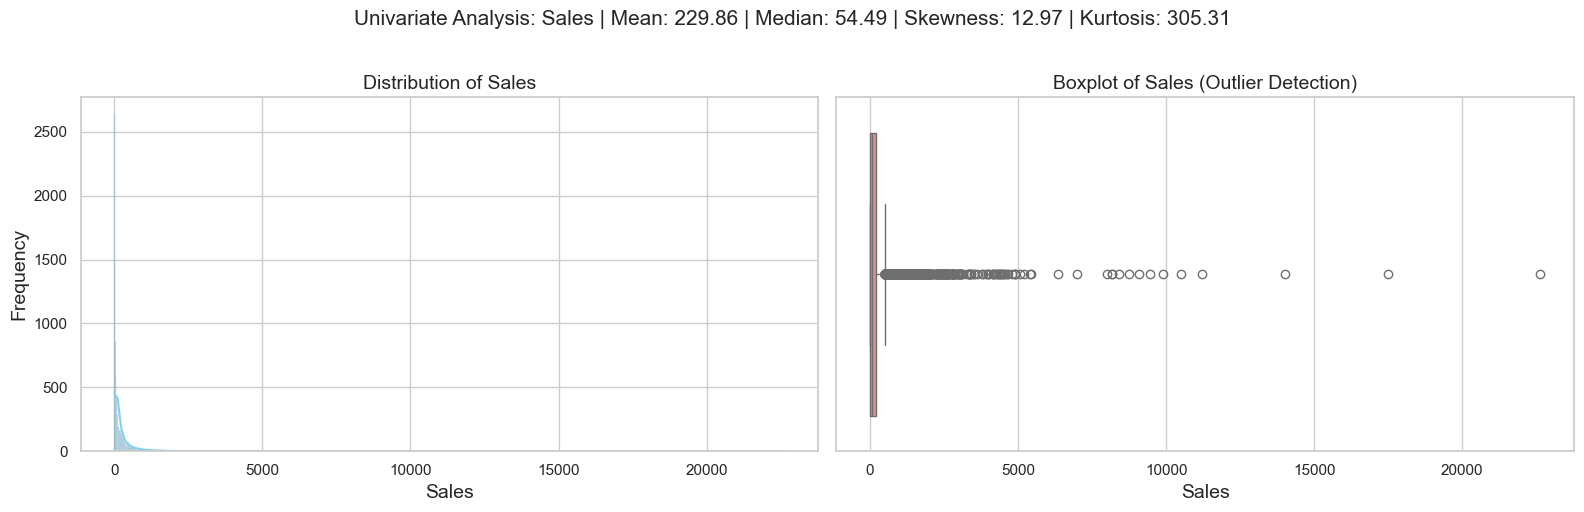

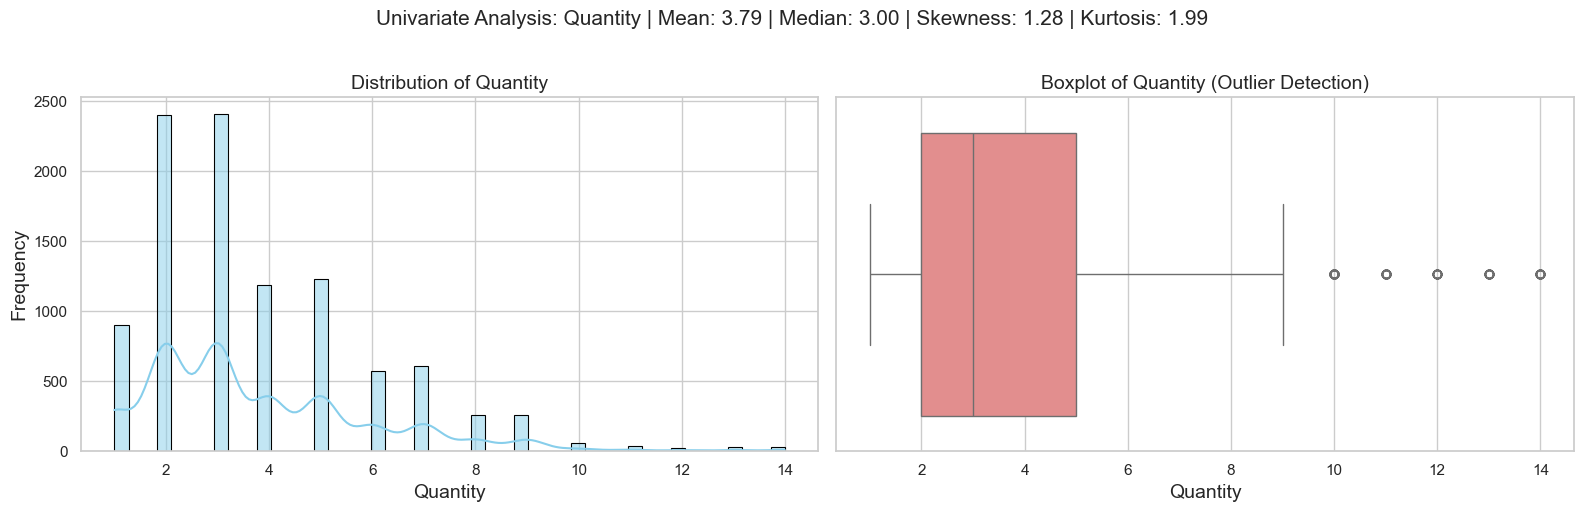

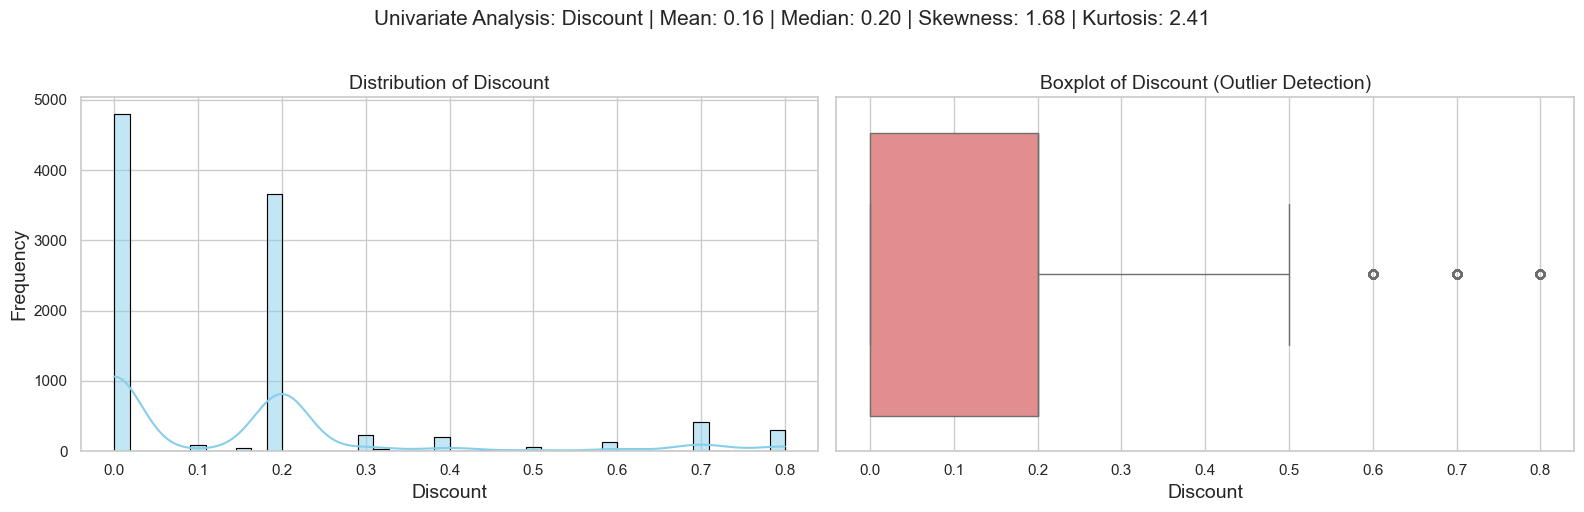

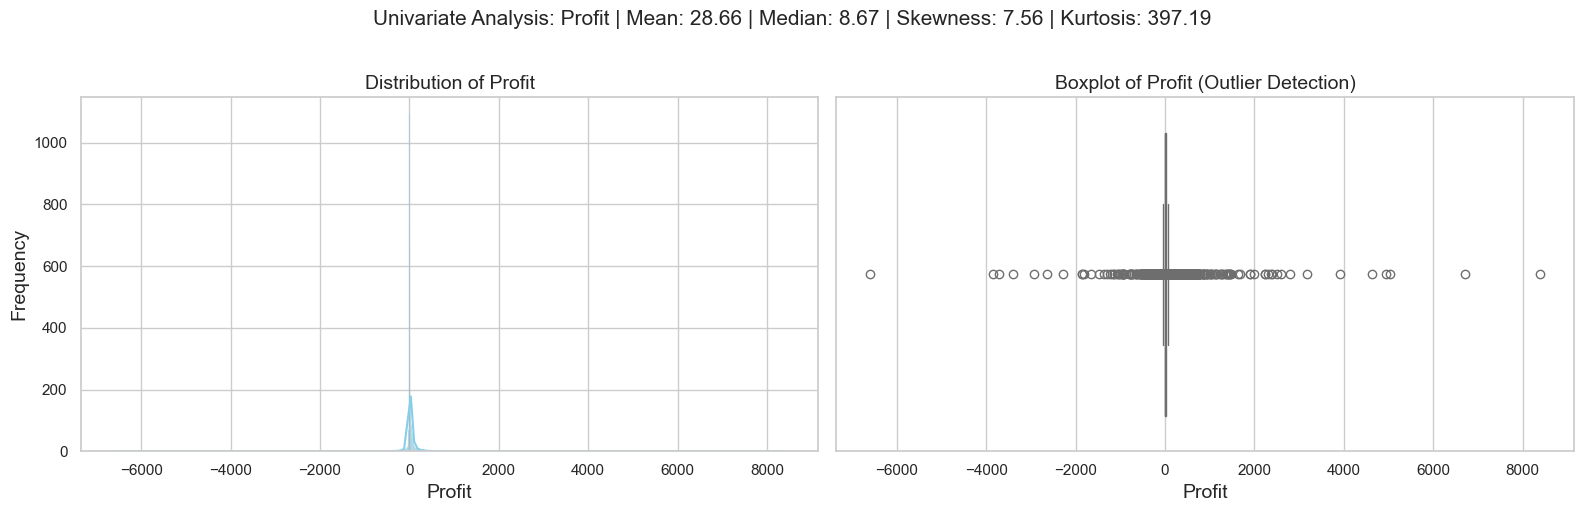

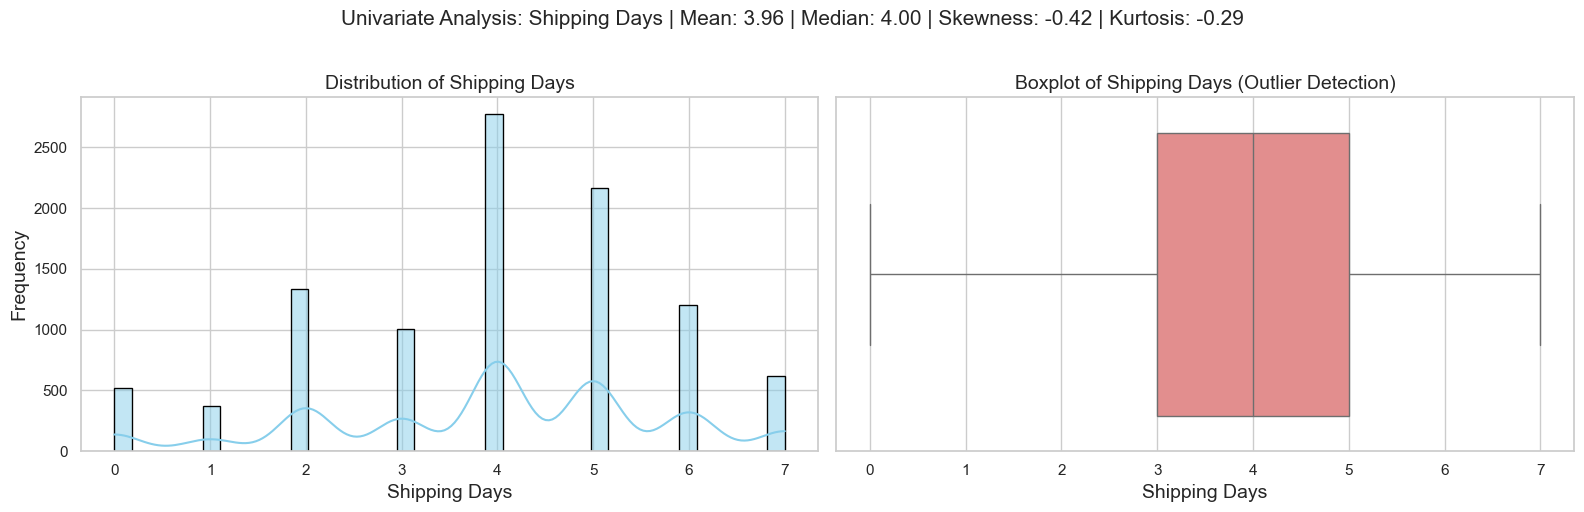

In [5]:
# Filter numerical columns to focus on main continuous features
plot_numerics = [col for col in numerical_cols if col.lower() not in ['year', 'month', 'quarter', 'row id']]

print(f"Generating univariate plots for {len(plot_numerics)} numerical columns.")

for col in plot_numerics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Histogram & KDE
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Distribution of {col}', fontsize=14)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot of {col} (Outlier Detection)', fontsize=14)
    axes[1].set_xlabel(col)
    
    # Statistics
    skewness = df[col].skew()
    kurt = df[col].kurt()
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    plt.suptitle(f'Univariate Analysis: {col} | Mean: {mean_val:.2f} | Median: {median_val:.2f} | Skewness: {skewness:.2f} | Kurtosis: {kurt:.2f}', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")


## 3. Univariate Analysis: Categorical Columns
We plot frequency distributions for our categorical columns. To maintain clean, readable visualizations:
- If a column has up to 15 unique values, we show all values.
- If it has more than 15, we show only the top 10 categories.
- We annotate each bar with the count and percentage, which adds transparency to category representations.


Generating count plots for 11 categorical columns.


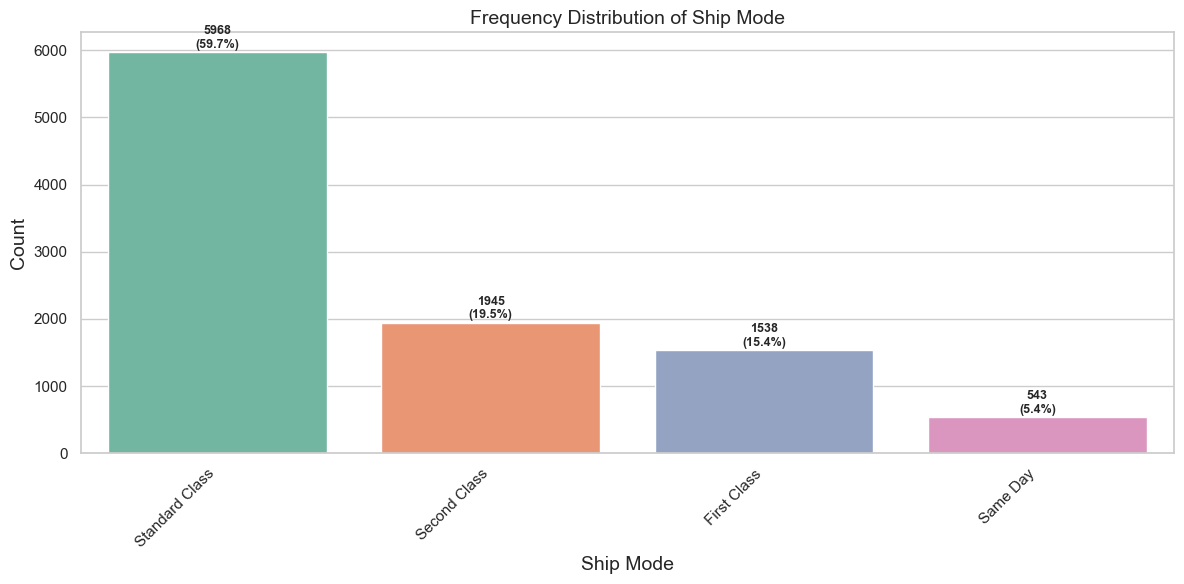

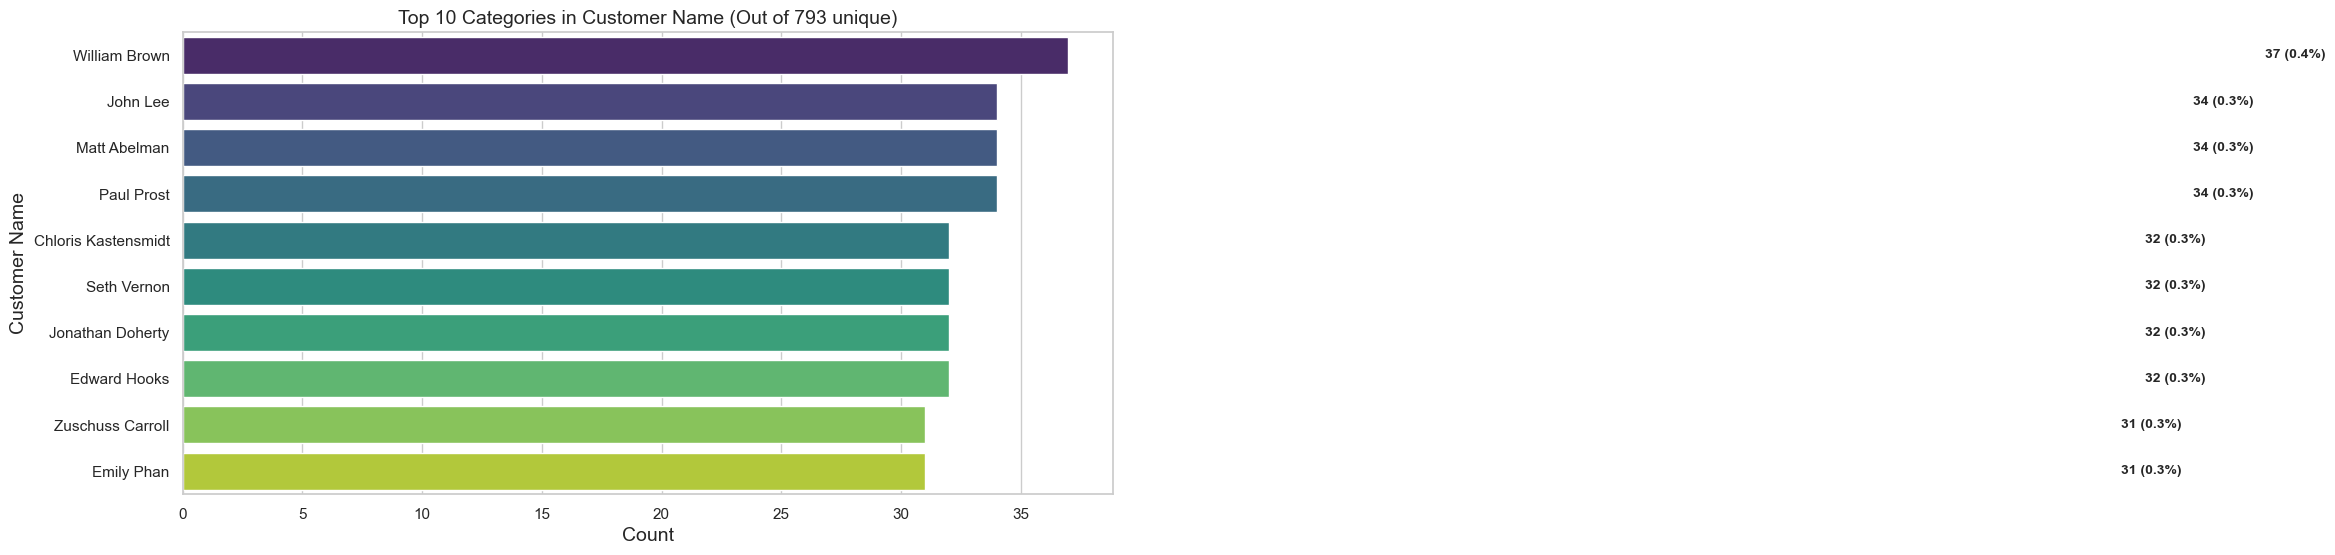

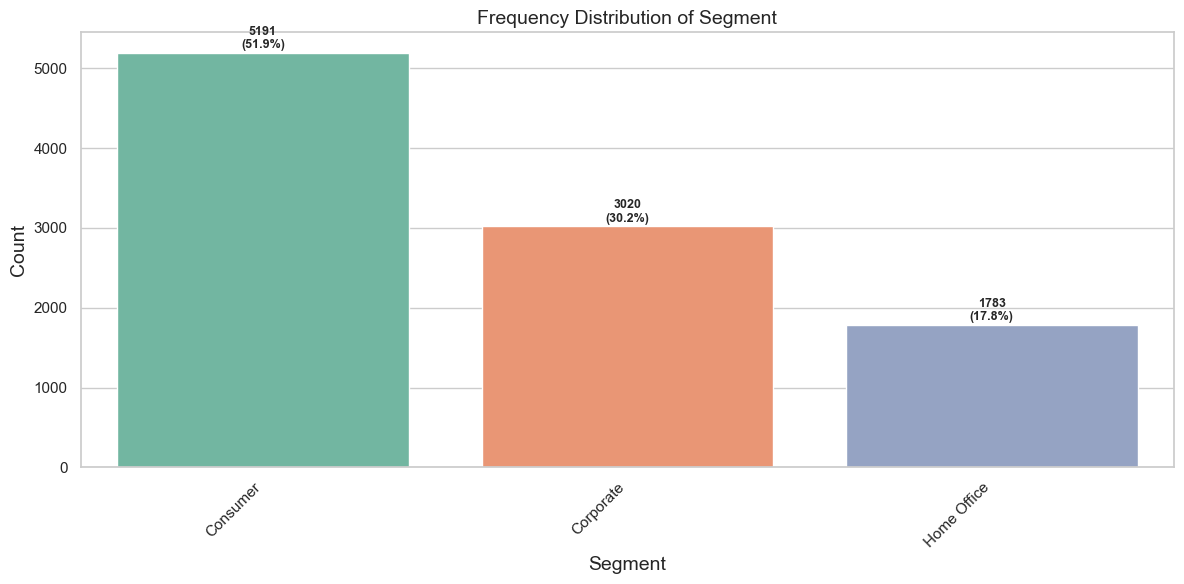

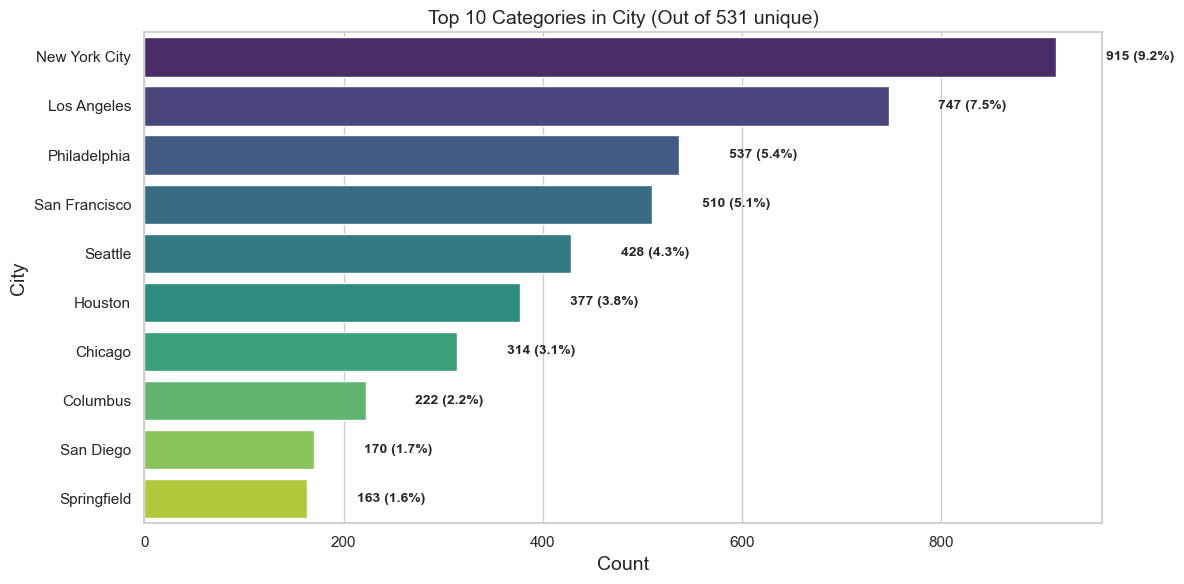

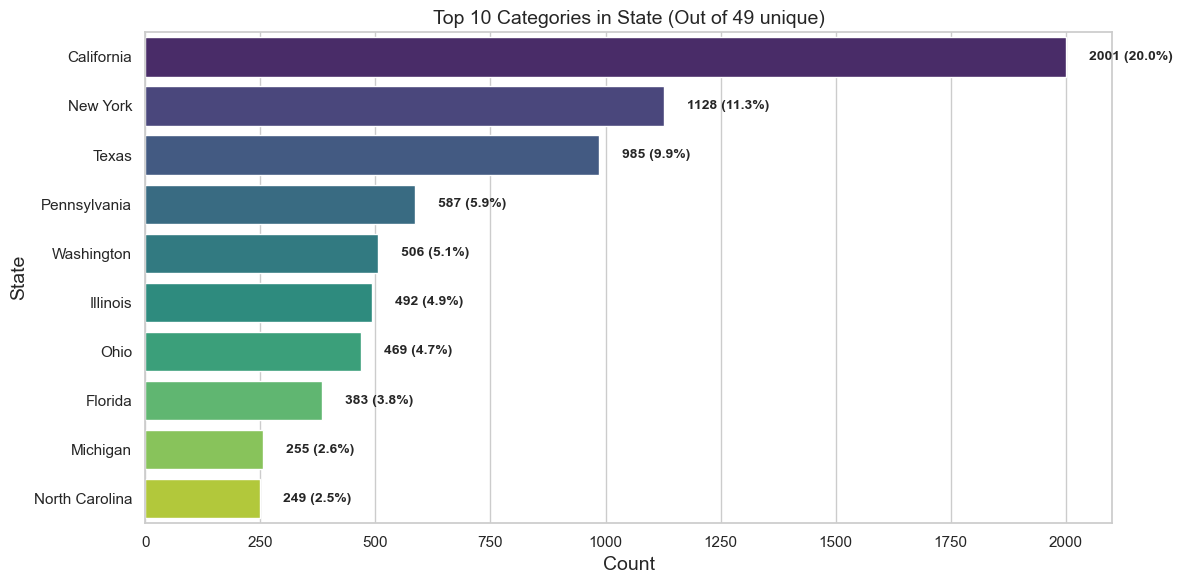

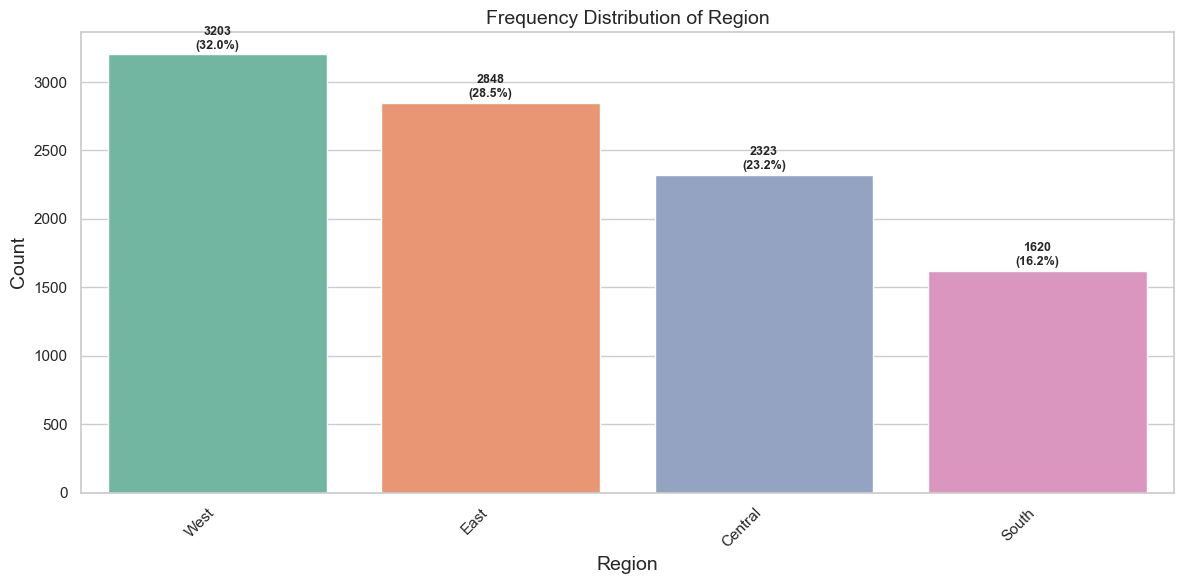

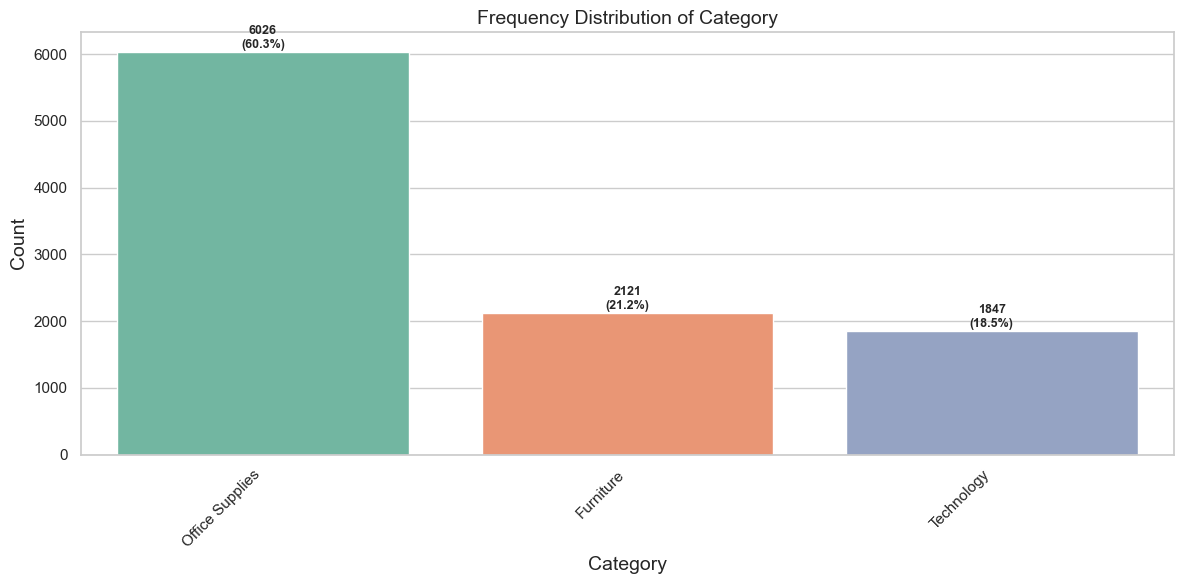

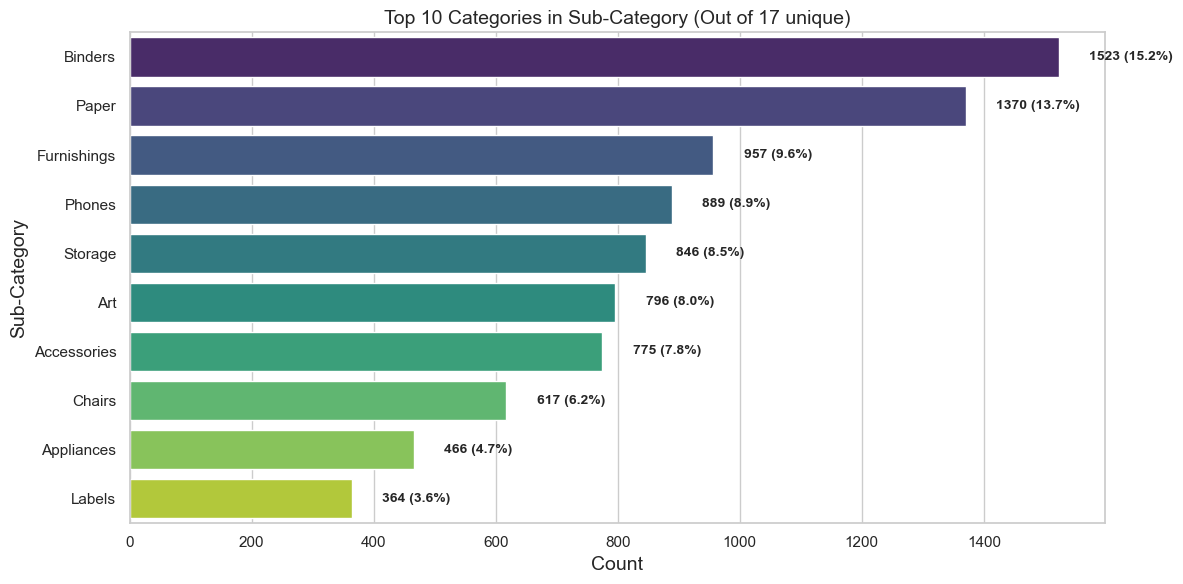

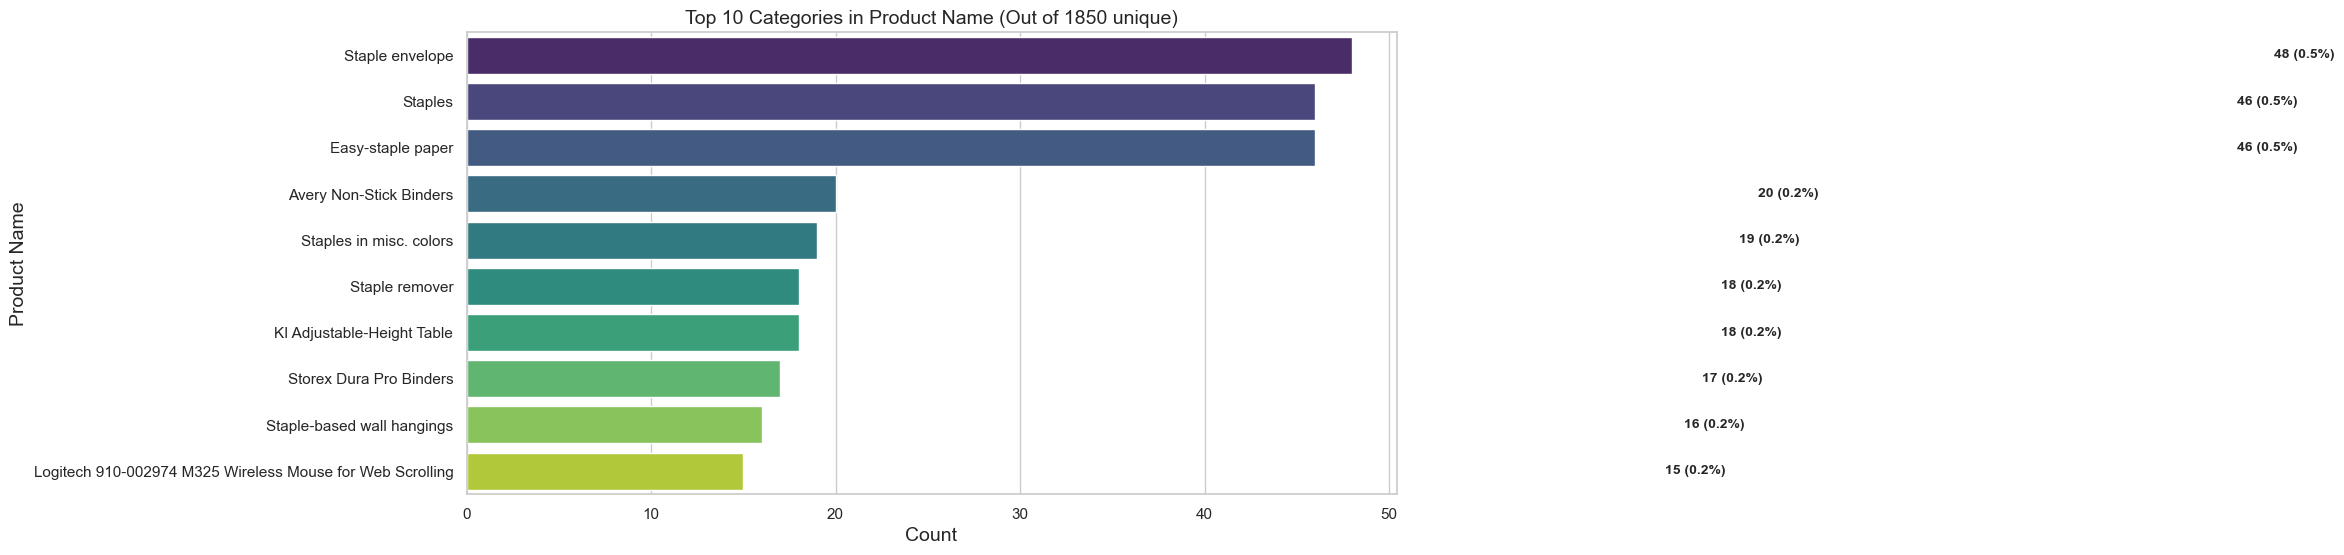

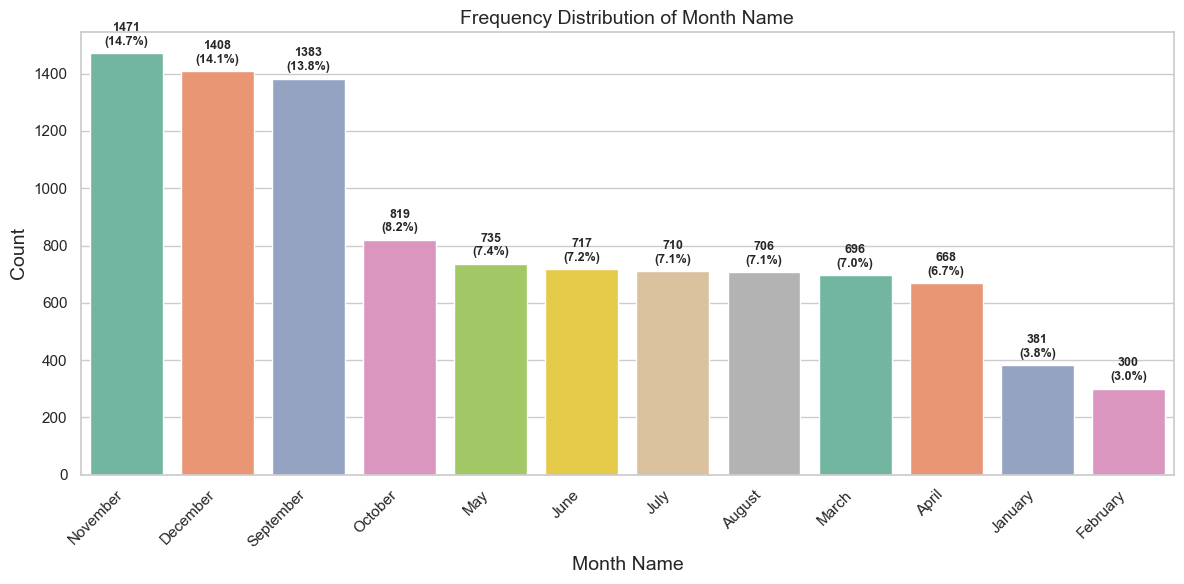

In [6]:
print(f"Generating count plots for {len(categorical_cols)} categorical columns.")

for col in categorical_cols:
    unique_count = df[col].nunique()
    if unique_count <= 1:
        continue  # Skip columns with no variation
    
    plt.figure(figsize=(12, 6))
    
    if unique_count > 15:
        # Plot top 10 categories horizontally for high-cardinality columns
        order = df[col].value_counts().iloc[:10].index
        sns.countplot(data=df[df[col].isin(order)], y=col, order=order, palette='viridis')
        plt.title(f'Top 10 Categories in {col} (Out of {unique_count} unique)', fontsize=14)
        plt.xlabel('Count')
        plt.ylabel(col)
    else:
        # Plot standard count plot vertically
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, palette='Set2')
        plt.title(f'Frequency Distribution of {col}', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel(col)
        plt.ylabel('Count')
        
    # Annotate bars
    ax = plt.gca()
    total = len(df)
    if unique_count > 15:
        for p in ax.patches:
            width = p.get_width()
            pct = (width / total) * 100
            ax.text(width + total*0.005, p.get_y() + p.get_height()/2, f'{int(width)} ({pct:.1f}%)', 
                    va='center', ha='left', fontsize=10, weight='bold')
    else:
        for p in ax.patches:
            height = p.get_height()
            pct = (height / total) * 100
            ax.text(p.get_x() + p.get_width()/2., height + total*0.002, f'{int(height)}\n({pct:.1f}%)', 
                    ha="center", va="bottom", fontsize=9, weight='bold')
            
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")


## 4. Bivariate Analysis: Numerical Columns
We automatically identify pairs of variables with significant correlations and generate scatter plots with regression lines. This helps visualize how these variables co-vary (e.g. Sales and Profit).


Top Numerical Correlated Pairs to Visualize:
- Sales vs Profit: Correlation = 0.4791
- Discount vs Profit: Correlation = -0.2195
- Sales vs Quantity: Correlation = 0.2008

Generating regression plots:


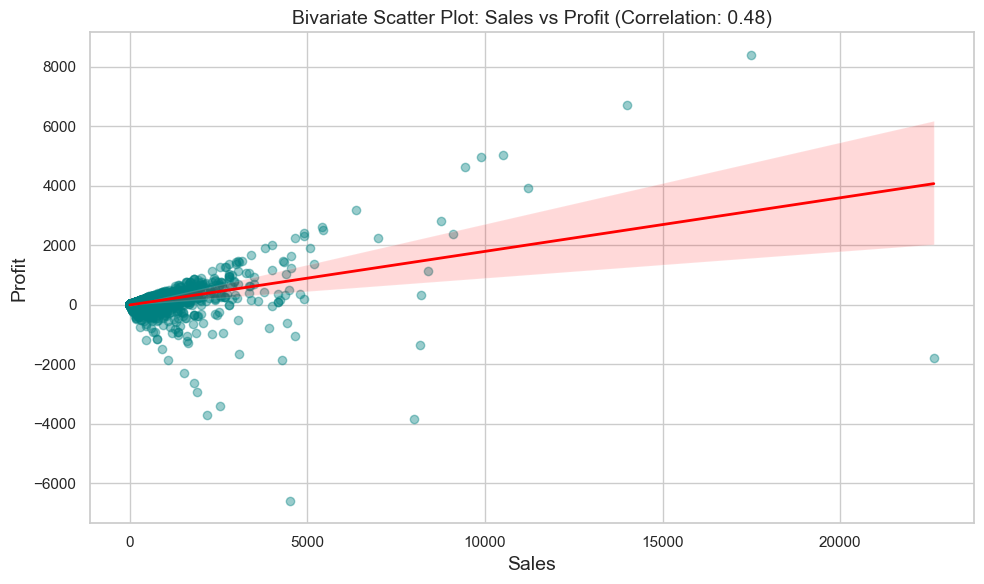

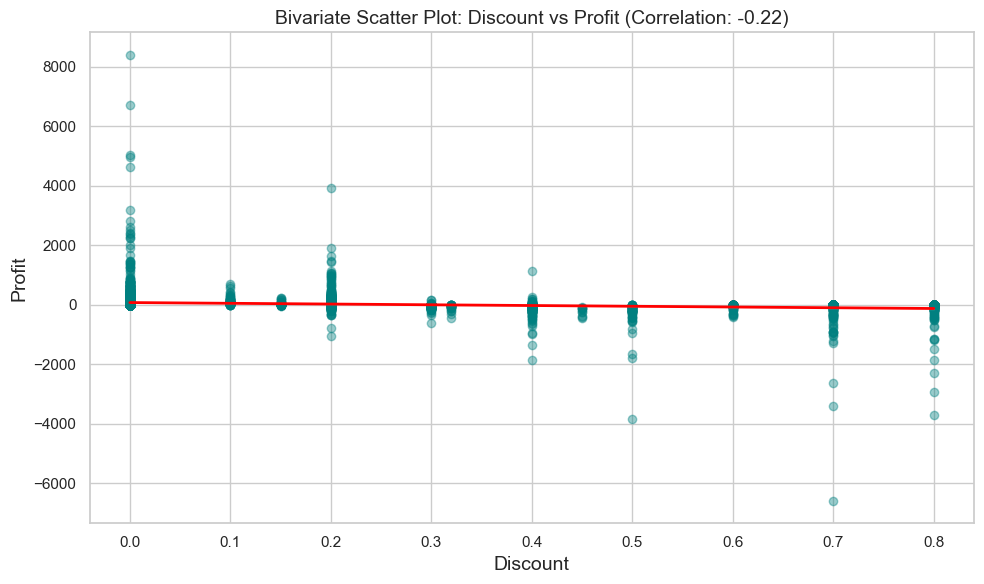

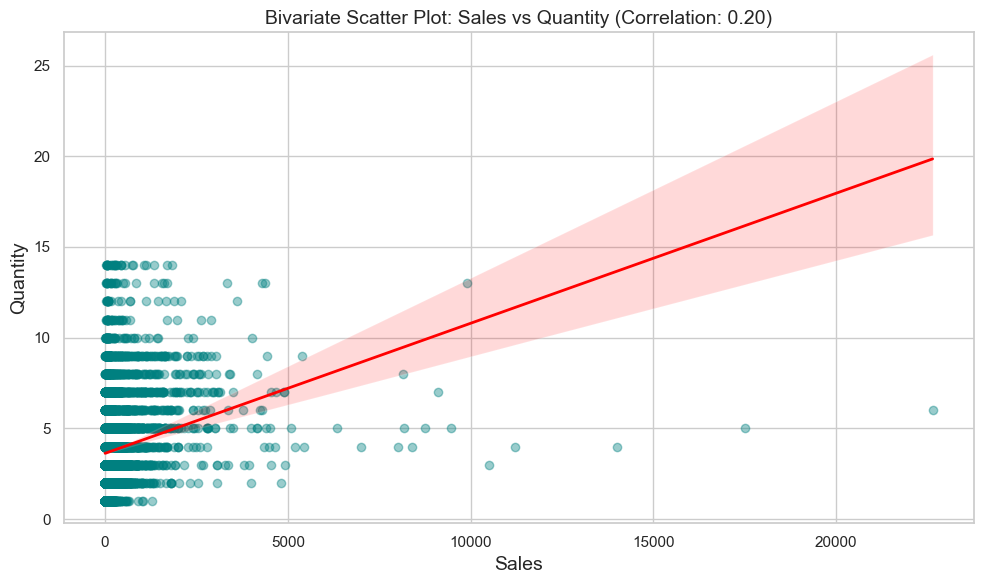

In [7]:
# Identify correlation matrix
corr = df[plot_numerics].corr()

# Extract unique pairs and sort by correlation magnitude
pairs = []
for i in range(len(plot_numerics)):
    for j in range(i+1, len(plot_numerics)):
        col1 = plot_numerics[i]
        col2 = plot_numerics[j]
        val = corr.loc[col1, col2]
        pairs.append((col1, col2, val))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
top_pairs = pairs_sorted[:3]

print("Top Numerical Correlated Pairs to Visualize:")
for col1, col2, val in top_pairs:
    print(f"- {col1} vs {col2}: Correlation = {val:.4f}")

print("\nGenerating regression plots:")
for col1, col2, val in top_pairs:
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x=col1, y=col2, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red', 'linewidth': 2})
    plt.title(f'Bivariate Scatter Plot: {col1} vs {col2} (Correlation: {val:.2f})', fontsize=14)
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")


## 4. Bivariate Analysis: Numerical vs Categorical
We compare the distributions and averages of key numerical columns (e.g. Sales, Profit, Shipping Days) across key categorical dimensions (e.g. Category, Segment, Region). For each combination, we present:
- **Boxplot (Left)**: To display distribution spread, median, quartiles, and outliers.
- **Barplot (Right)**: To display mean values with direct value annotations.


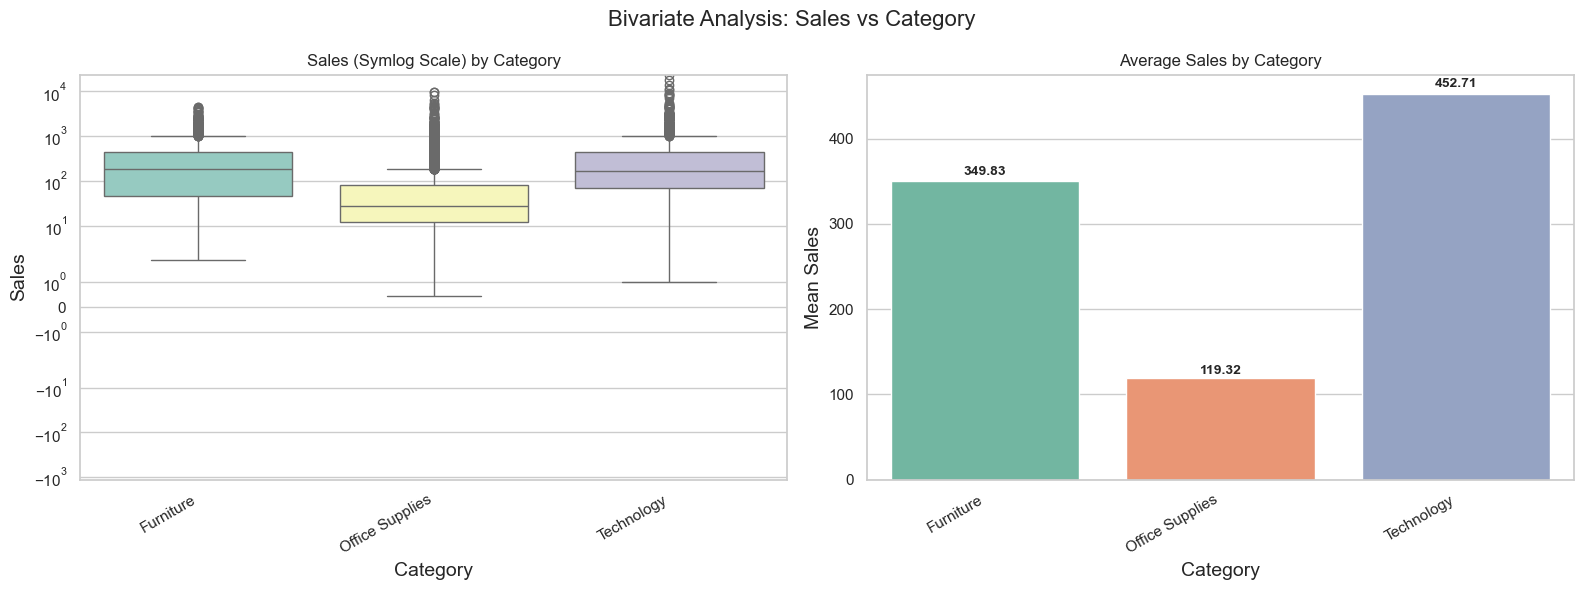

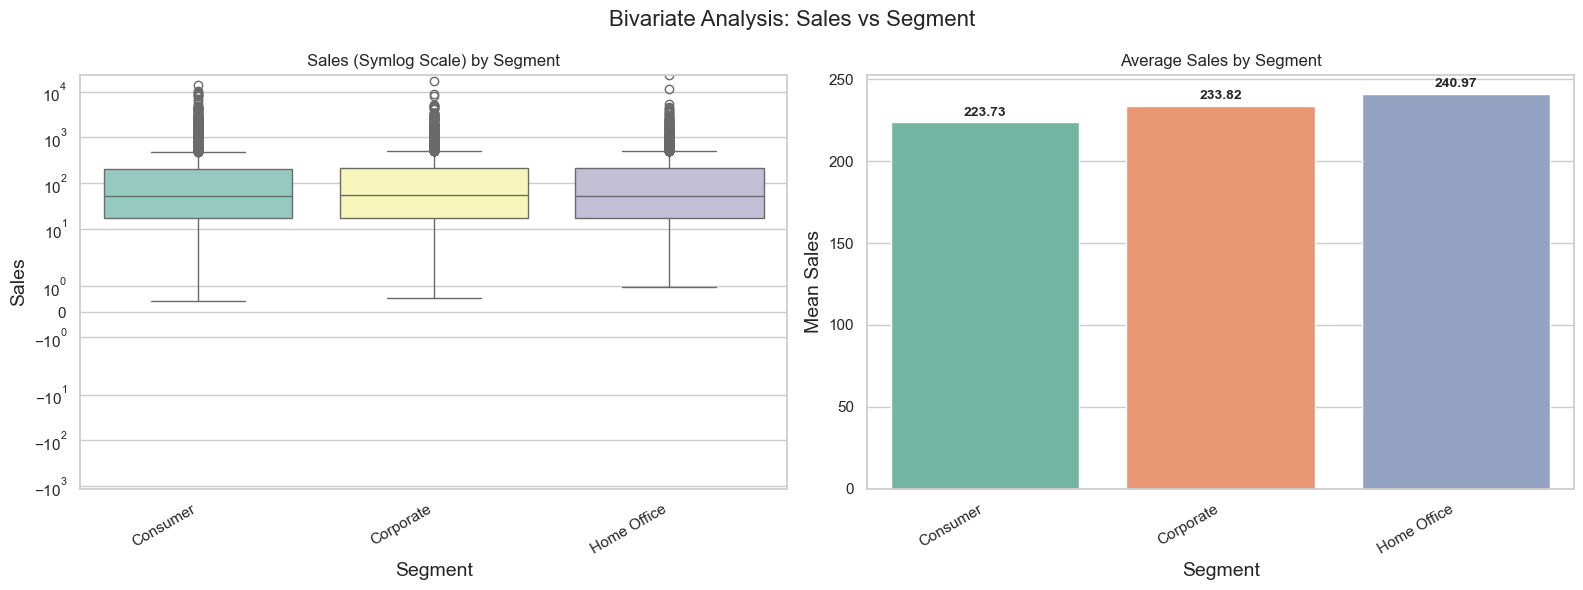

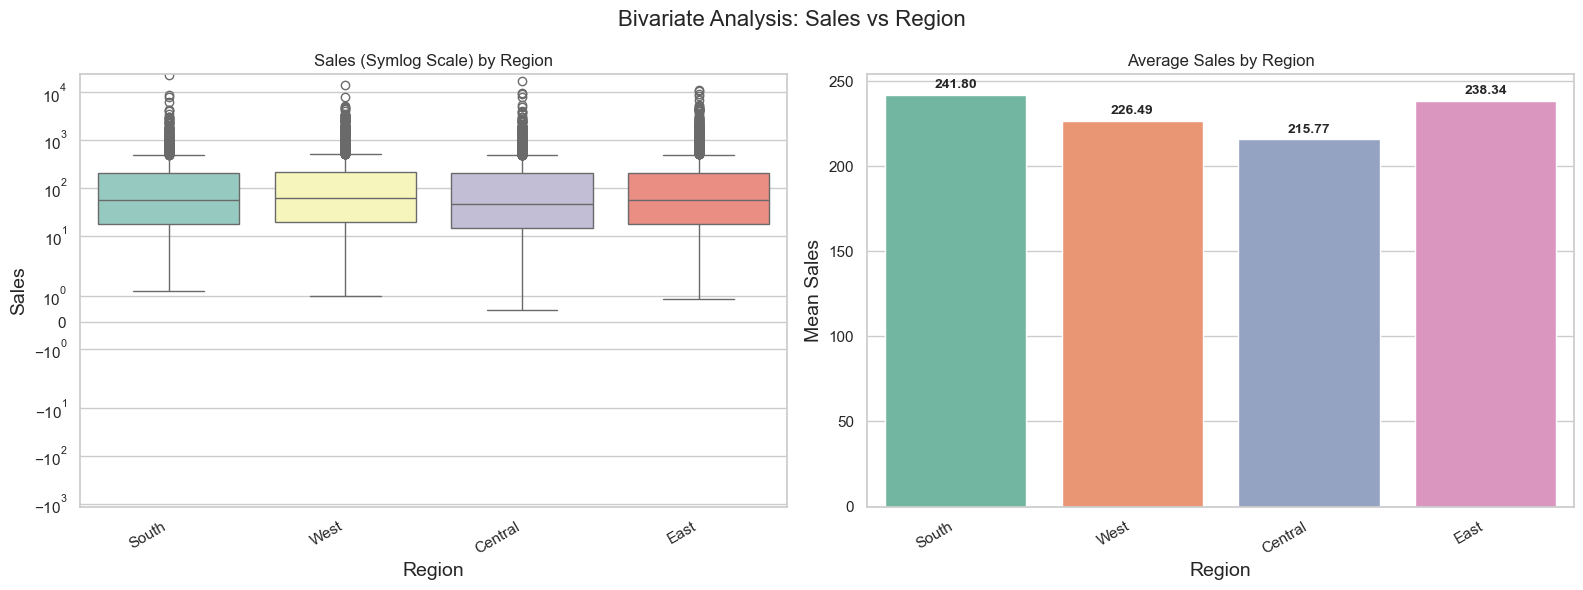

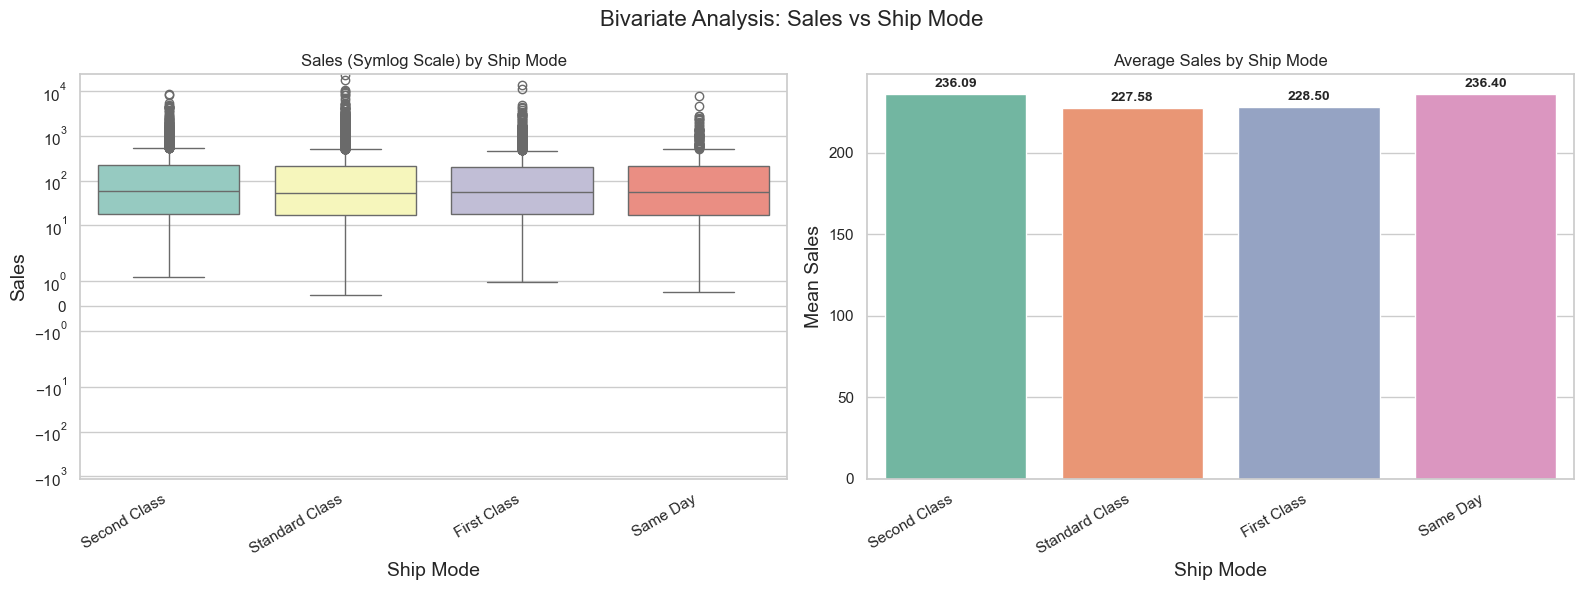

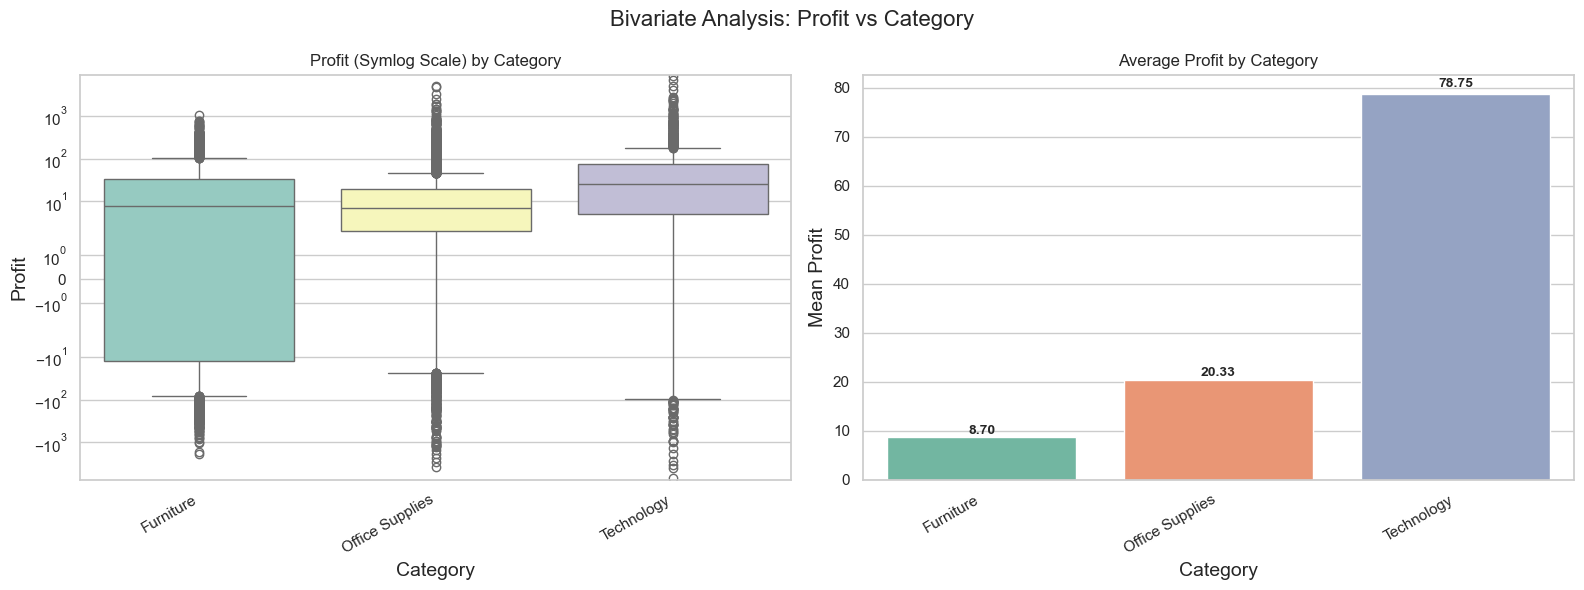

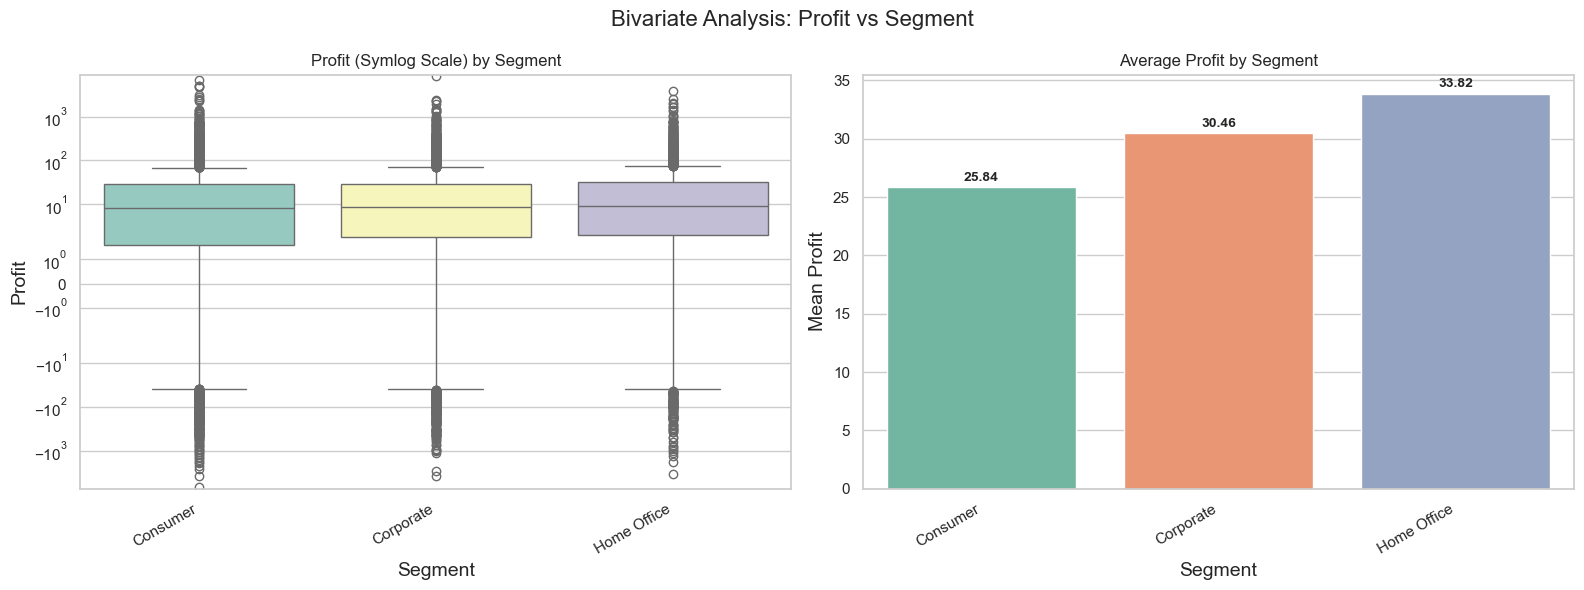

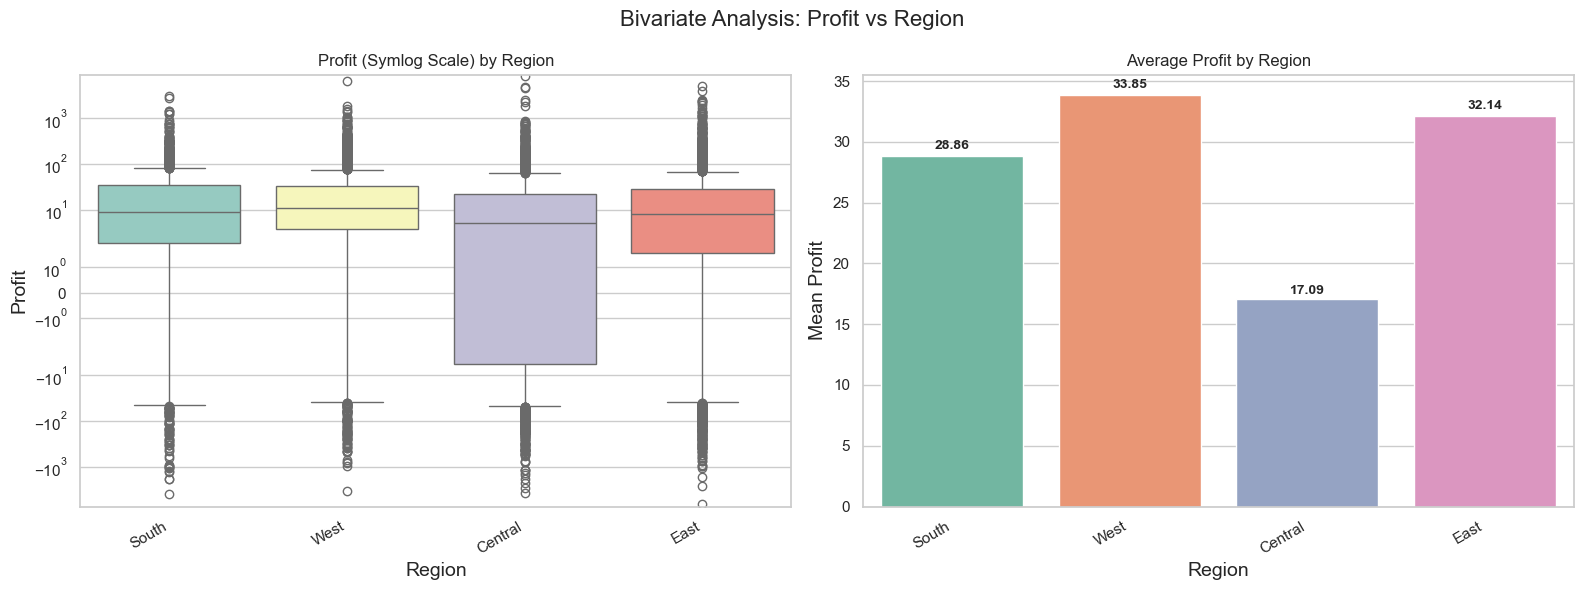

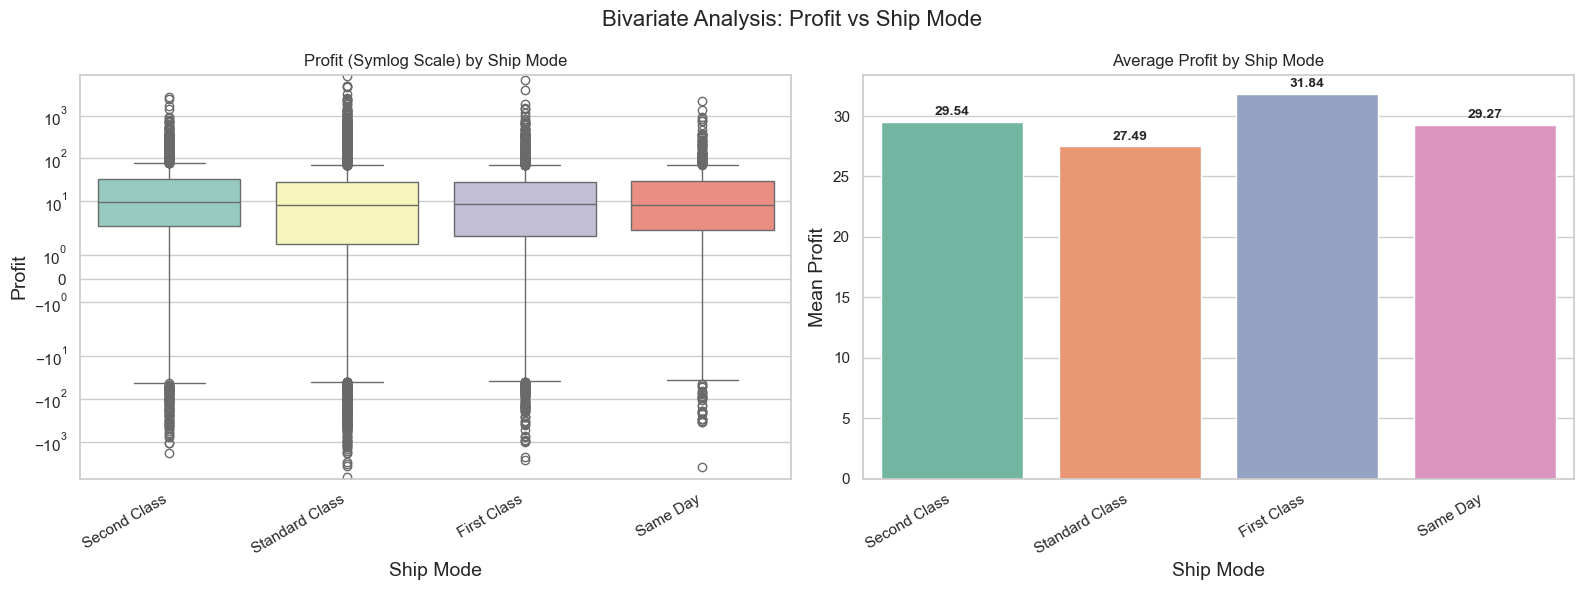

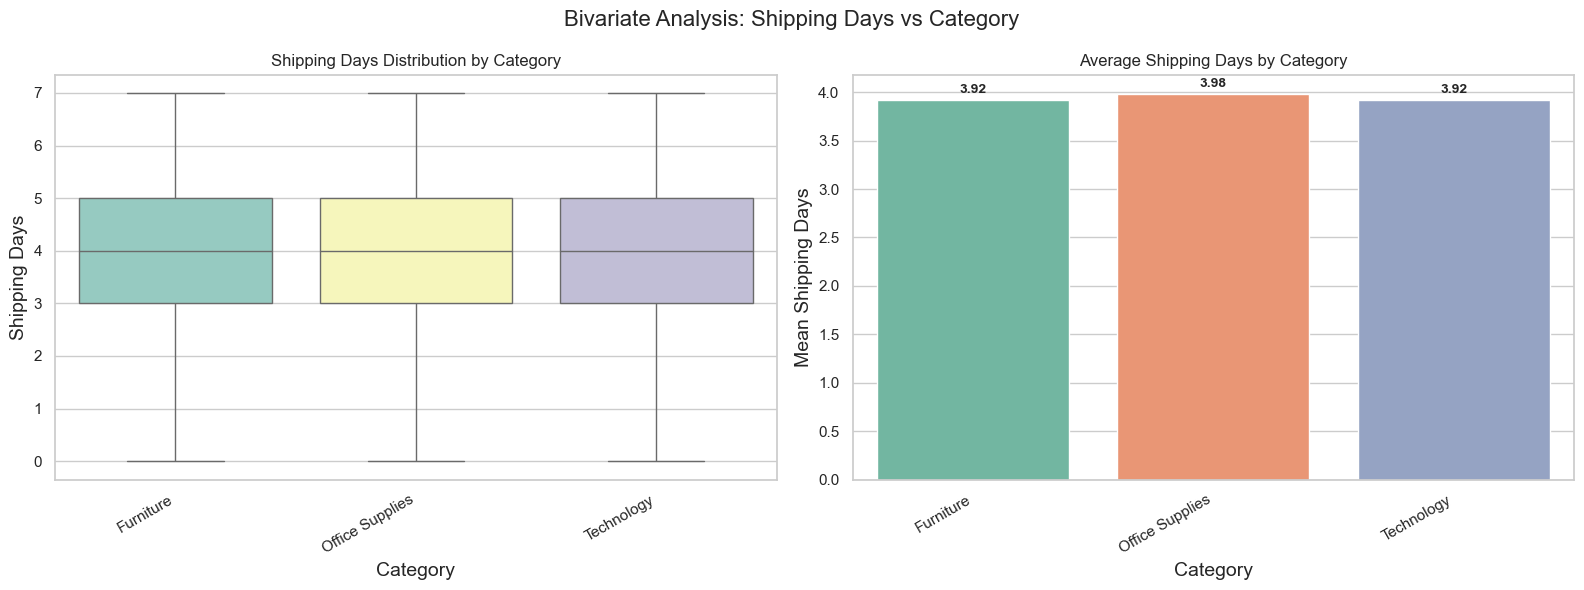

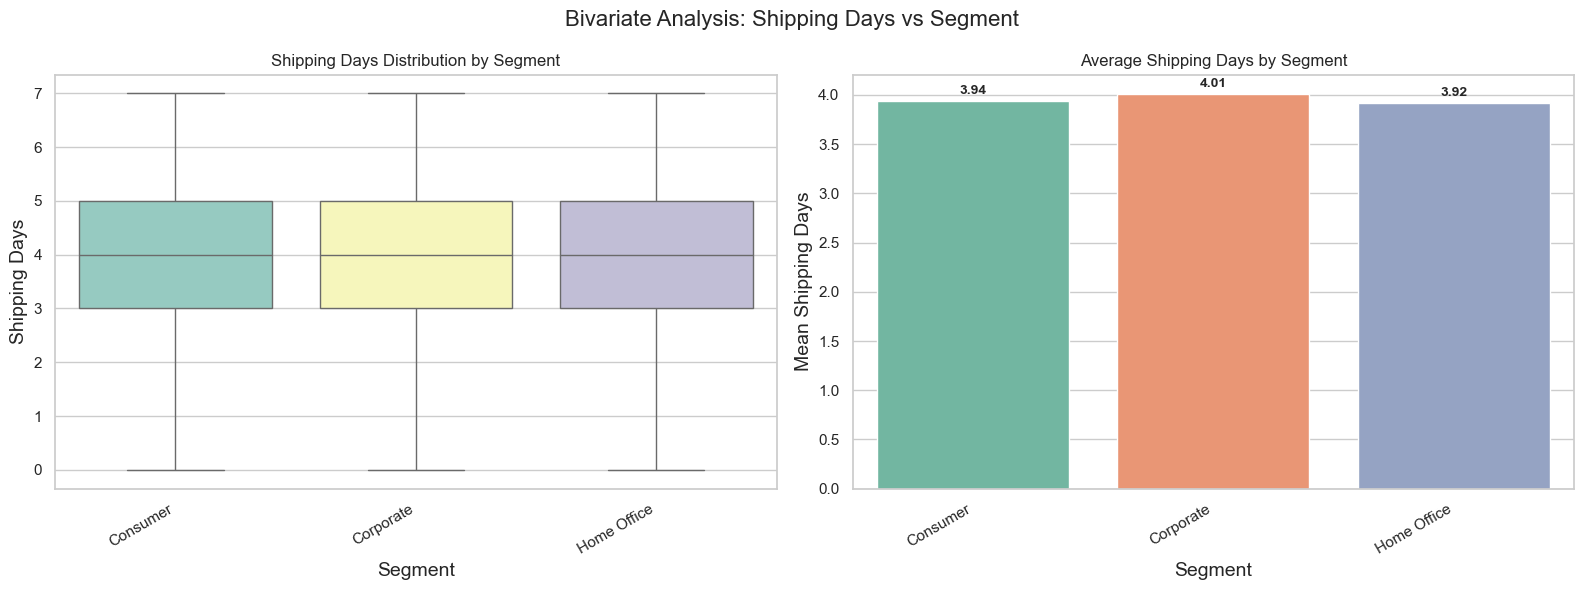

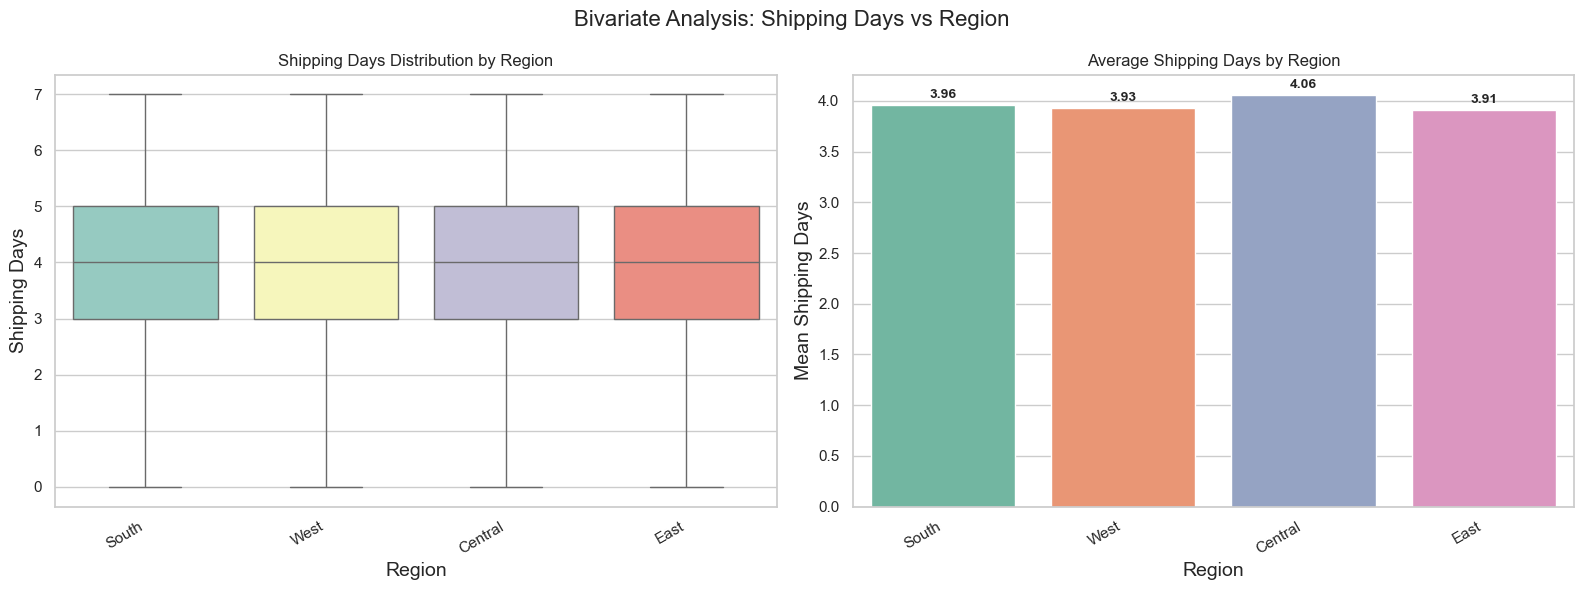

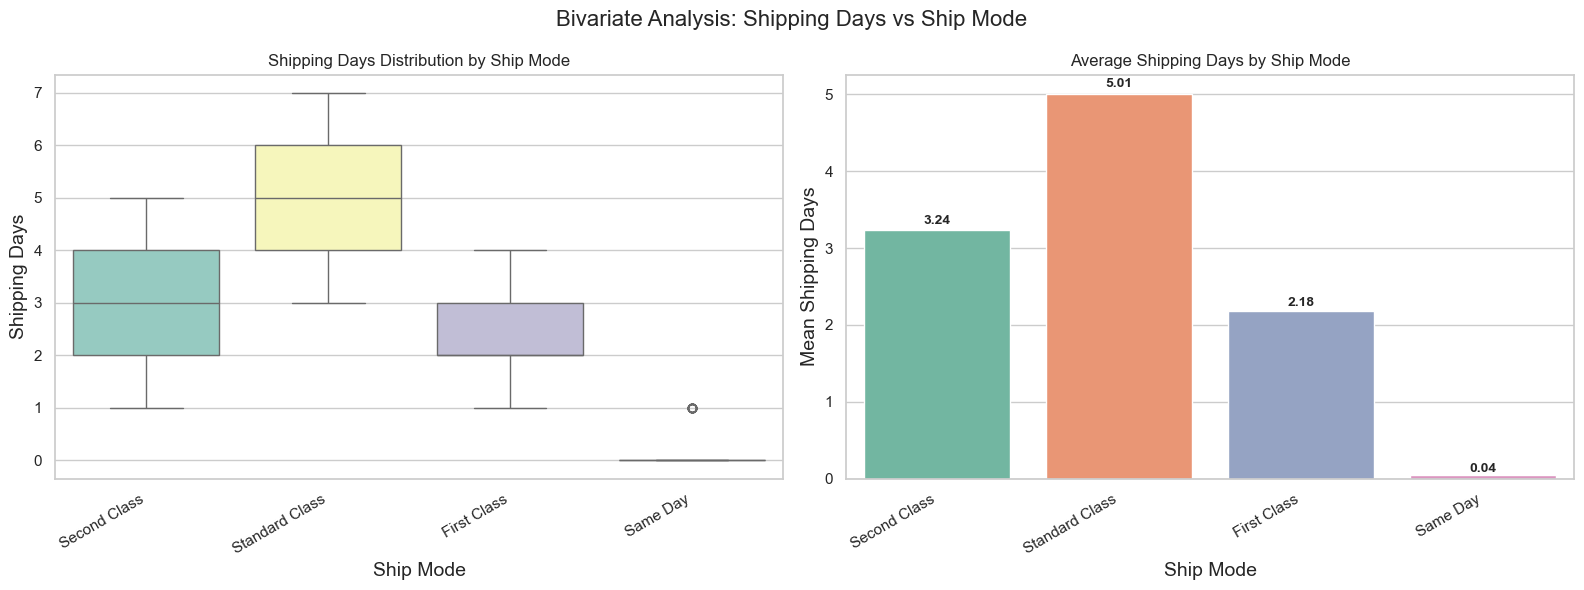

In [8]:
target_numerics = [c for c in ['Sales', 'Profit', 'Shipping Days'] if c in plot_numerics]
target_categoricals = [c for c in ['Category', 'Segment', 'Region', 'Ship Mode'] if c in categorical_cols]

# Fallbacks if target columns aren't present
if not target_numerics:
    target_numerics = plot_numerics[:2]
if not target_categoricals:
    target_categoricals = categorical_cols[:2]

for num_col in target_numerics:
    for cat_col in target_categoricals:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # 1. Boxplot (log scale for highly skewed columns like Sales/Profit to keep it legible)
        # We apply log scale if values are mostly positive and highly skewed
        apply_log = num_col == 'Sales' or (num_col == 'Profit' and (df[num_col] > 0).sum() > len(df)*0.8)
        
        if apply_log:
            sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[0], palette='Set3')
            axes[0].set_yscale('symlog')  # symlog supports negative values (for profit)
            axes[0].set_title(f'{num_col} (Symlog Scale) by {cat_col}', fontsize=12)
        else:
            sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[0], palette='Set3')
            axes[0].set_title(f'{num_col} Distribution by {cat_col}', fontsize=12)
            
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
        axes[0].set_xlabel(cat_col)
        axes[0].set_ylabel(num_col)
        
        # 2. Barplot (mean values, no log scale so we see actual values)
        sns.barplot(data=df, x=cat_col, y=num_col, ax=axes[1], palette='Set2', errorbar=None)
        axes[1].set_title(f'Average {num_col} by {cat_col}', fontsize=12)
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
        axes[1].set_xlabel(cat_col)
        axes[1].set_ylabel(f'Mean {num_col}')
        
        # Annotate mean values on the barplot
        for p in axes[1].patches:
            height = p.get_height()
            offset = height * 0.01 if height > 0 else height * 0.05
            axes[1].text(p.get_x() + p.get_width()/2., height + offset,
                         f'{height:.2f}', ha="center", va="bottom", fontsize=10, weight='bold')
            
        plt.suptitle(f'Bivariate Analysis: {num_col} vs {cat_col}', fontsize=16)
        plt.tight_layout()
        plt.show()
        print("\n" + "="*80 + "\n")


## 5. Multivariate Analysis
We evaluate multi-dimensional relationships:
1. **Correlation Heatmap**: Visualizes linear correlation among all numerical variables. We apply a diagonal mask to avoid duplicate lookups.
2. **Pairplot**: Visualizes scatter distributions of all numerical combinations, color-coded by a key categorical dimension (e.g., Segment) to observe interactions.
3. **Sales vs. Profit 3D Scatter (represented in 2D)**: Plots Sales vs Profit, sized by Quantity and colored by Discount percentage.


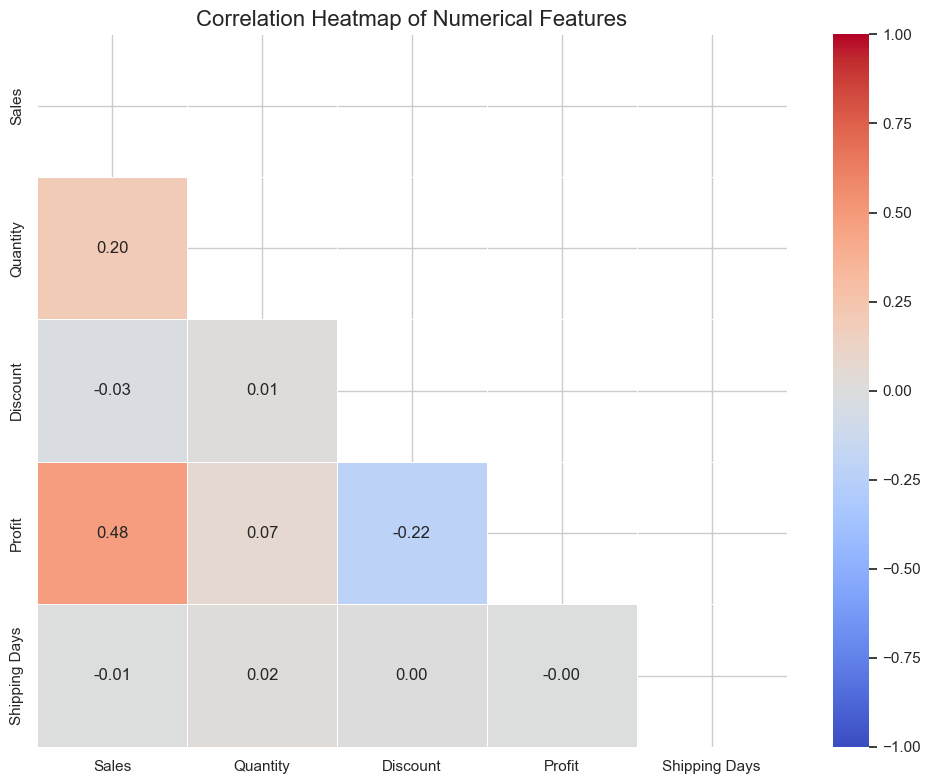



Generating pairplot for ['Sales', 'Quantity', 'Discount', 'Profit'] color-coded by 'Segment'...


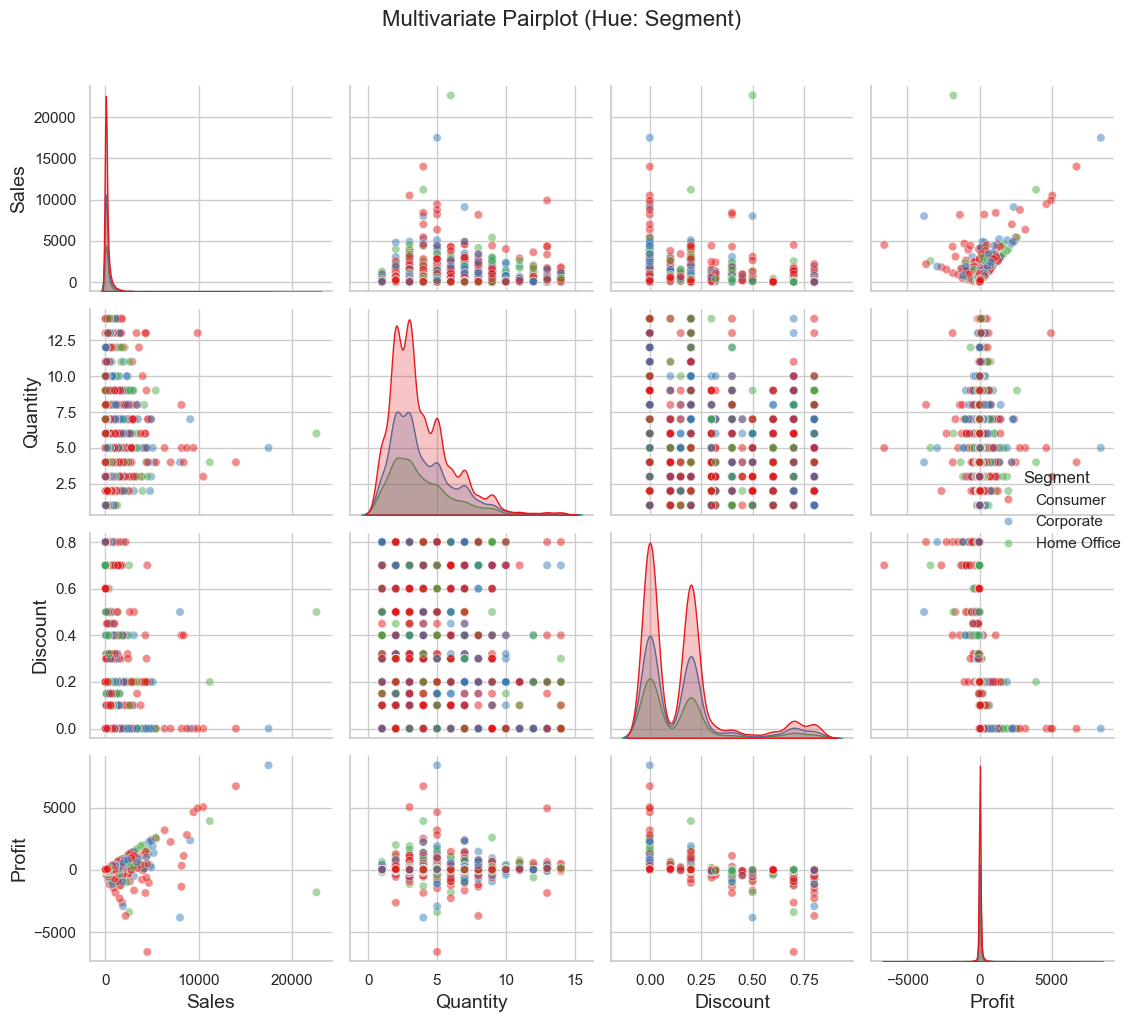

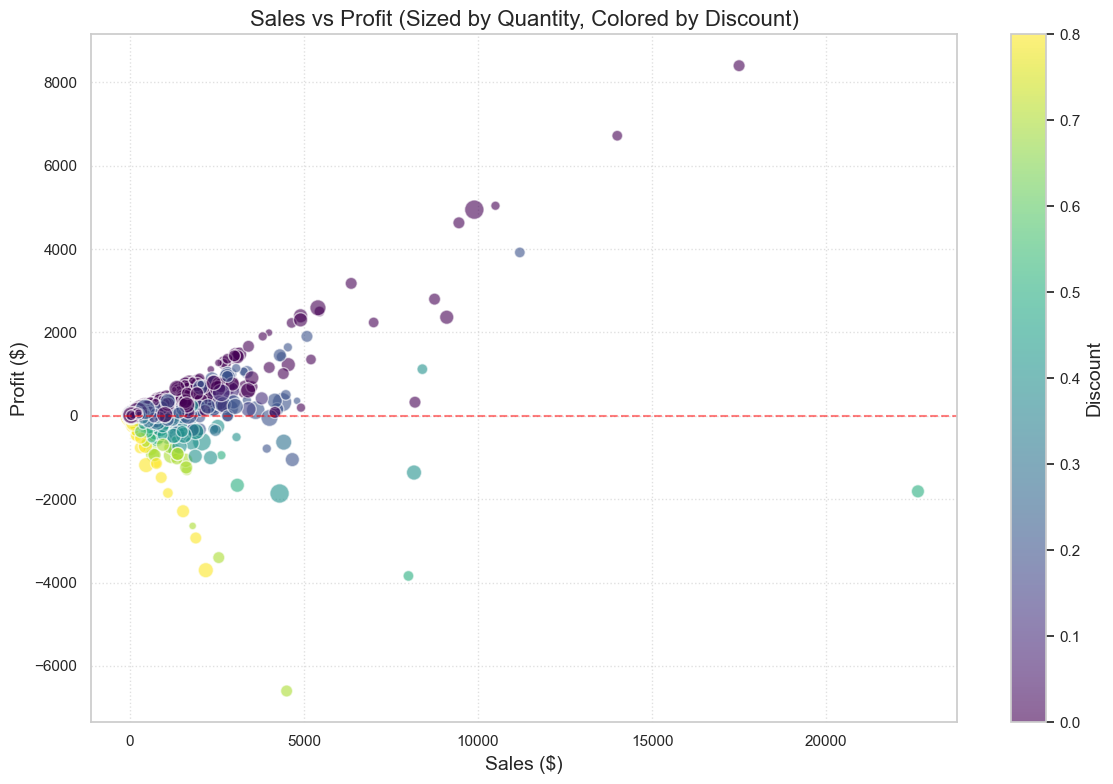

In [9]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()
print("\n" + "="*80 + "\n")

# 2. Pairplot
pairplot_nums = [c for c in ['Sales', 'Quantity', 'Discount', 'Profit'] if c in plot_numerics]
hue_col = None
# Select a low-cardinality categorical variable for coloring
for c in ['Segment', 'Category', 'Region']:
    if c in categorical_cols and df[c].nunique() <= 4:
        hue_col = c
        break

if len(pairplot_nums) >= 2:
    print(f"Generating pairplot for {pairplot_nums} color-coded by '{hue_col}'...")
    sns.pairplot(df, vars=pairplot_nums, hue=hue_col, palette='Set1', diag_kind='kde', plot_kws={'alpha':0.5})
    plt.suptitle(f'Multivariate Pairplot (Hue: {hue_col})', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")

# 3. Multi-dimensional Scatter Plot
if 'Sales' in df.columns and 'Profit' in df.columns and 'Discount' in df.columns:
    plt.figure(figsize=(12, 8))
    # Sized by Quantity, Colored by Discount
    scatter = plt.scatter(df['Sales'], df['Profit'], c=df['Discount'], s=df['Quantity']*15, cmap='viridis', alpha=0.6, edgecolors='w')
    plt.colorbar(scatter, label='Discount')
    plt.title('Sales vs Profit (Sized by Quantity, Colored by Discount)', fontsize=16)
    plt.xlabel('Sales ($)')
    plt.ylabel('Profit ($)')
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


## 6. Time Series Analysis
If date columns are present, we extract the temporal trends. We analyze:
1. **Monthly Sales & Profit Trend Lines**: Showing performance changes over years.
2. **Yearly Sales & Profit Growth**: Highlights overall annual trajectory.
3. **Monthly Seasonality**: Average sales per calendar month to reveal seasonal peaks (holiday shopping, end-of-year clearances).


Date columns found: ['Order Date', 'Ship Date']
Using Order Date for time series analysis.


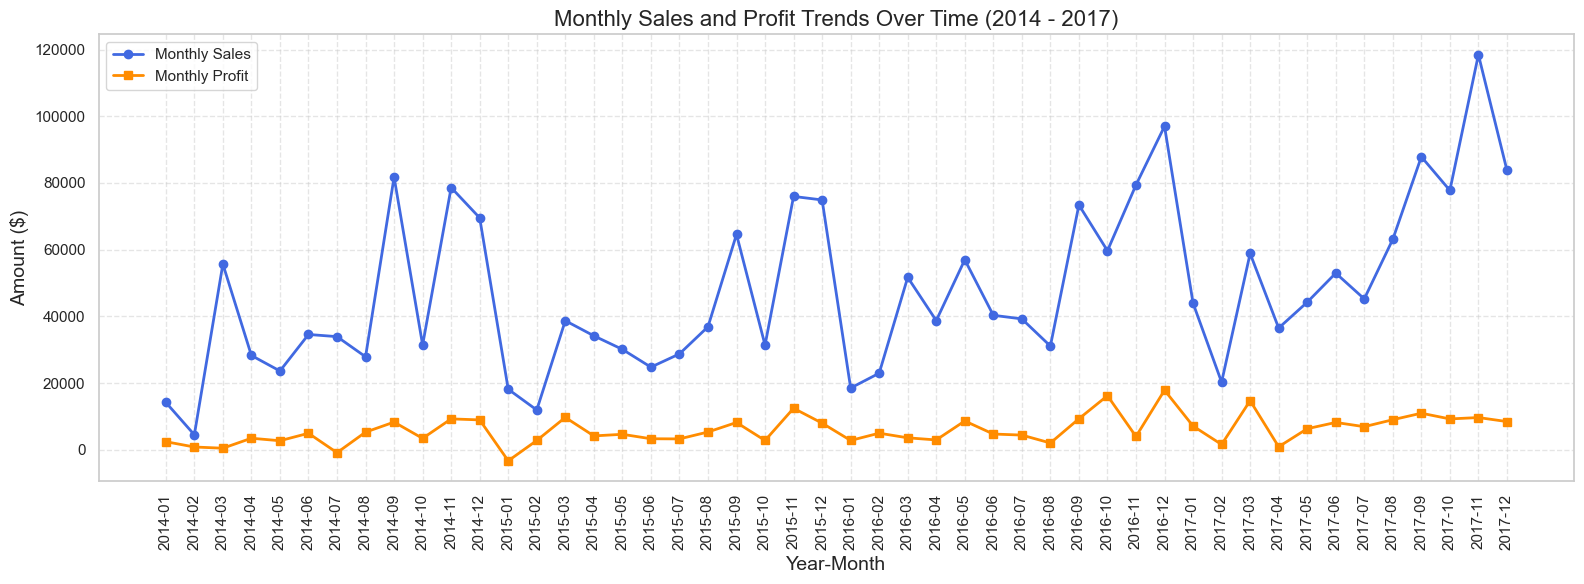

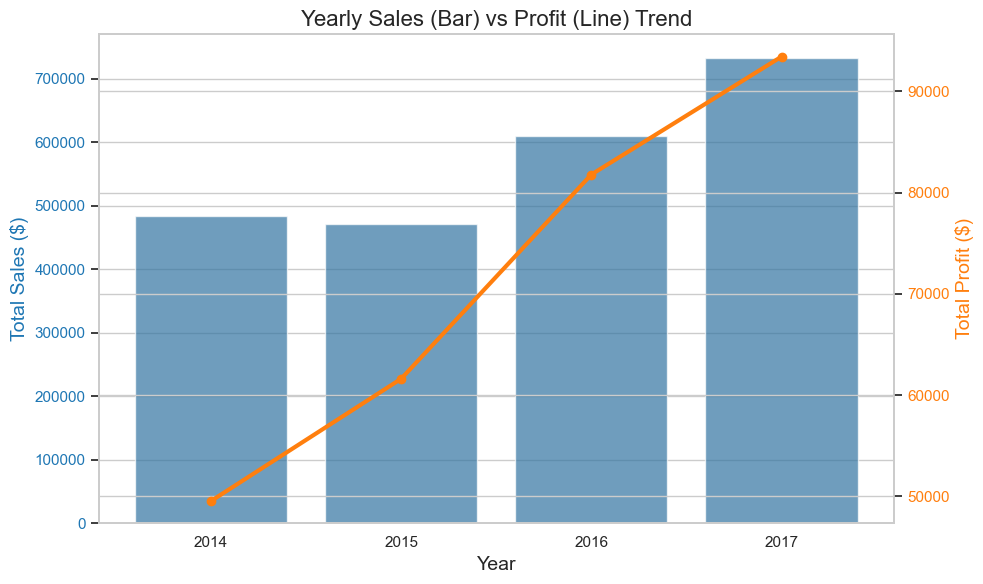

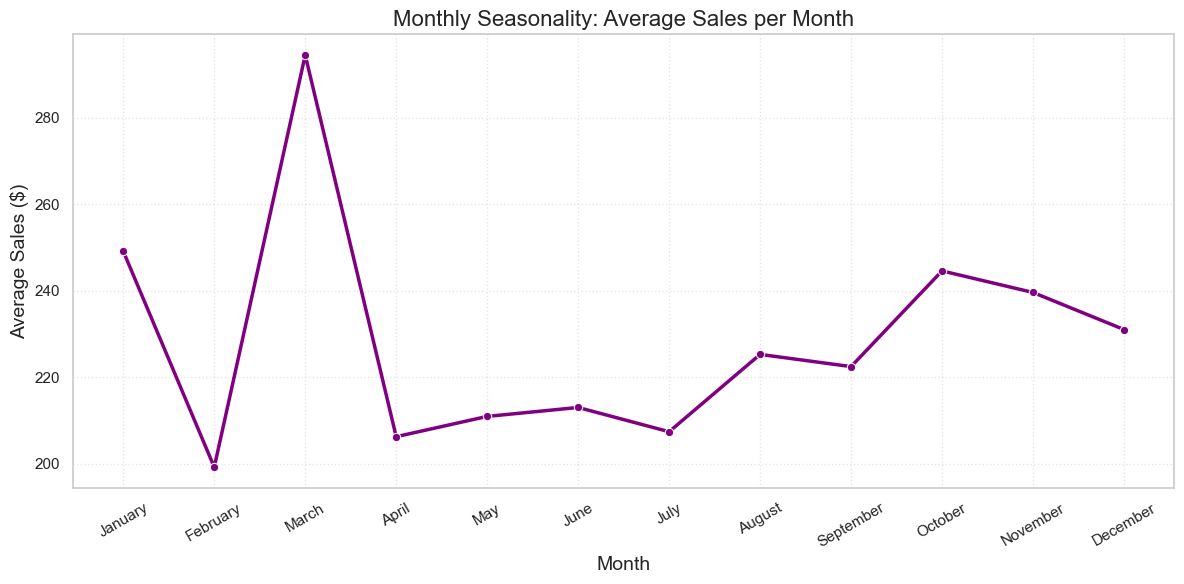

In [10]:
if datetime_cols:
    print(f"Date columns found: {datetime_cols}")
    date_col = datetime_cols[0]
    print(f"Using {date_col} for time series analysis.")
    
    # Sort dataset by date
    ts_df = df.sort_values(by=date_col).copy()
    
    # Extract temporal periods
    ts_df['YearMonth'] = ts_df[date_col].dt.to_period('M')
    ts_df['Year'] = ts_df[date_col].dt.year
    ts_df['MonthNum'] = ts_df[date_col].dt.month
    ts_df['MonthName'] = ts_df[date_col].dt.strftime('%B')
    
    # 1. Monthly Performance
    monthly_data = ts_df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()
    monthly_data['YearMonth_Str'] = monthly_data['YearMonth'].astype(str)
    
    plt.figure(figsize=(16, 6))
    plt.plot(monthly_data['YearMonth_Str'], monthly_data['Sales'], marker='o', label='Monthly Sales', color='royalblue', linewidth=2)
    plt.plot(monthly_data['YearMonth_Str'], monthly_data['Profit'], marker='s', label='Monthly Profit', color='darkorange', linewidth=2)
    plt.title(f'Monthly Sales and Profit Trends Over Time ({ts_df[date_col].dt.year.min()} - {ts_df[date_col].dt.year.max()})', fontsize=16)
    plt.xlabel('Year-Month')
    plt.ylabel('Amount ($)')
    # Show labels dynamically by picking a subset to avoid overlap
    labels = monthly_data['YearMonth_Str'].values
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")
    
    # 2. Yearly trends
    yearly_data = ts_df.groupby('Year')[['Sales', 'Profit']].sum().reset_index()
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Total Sales ($)', color=color)
    sns.barplot(data=yearly_data, x='Year', y='Sales', ax=ax1, color=color, alpha=0.7)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Total Profit ($)', color=color)
    ax2.plot(ax1.get_xticks(), yearly_data['Profit'], color=color, marker='o', linewidth=3, label='Profit')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Yearly Sales (Bar) vs Profit (Line) Trend', fontsize=16)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")
    
    # 3. Monthly Seasonality
    season_data = ts_df.groupby(['MonthNum', 'MonthName'])[['Sales', 'Profit']].mean().reset_index().sort_values('MonthNum')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=season_data, x='MonthName', y='Sales', marker='o', color='purple', linewidth=2.5, sort=False)
    plt.title('Monthly Seasonality: Average Sales per Month', fontsize=16)
    plt.xlabel('Month')
    plt.ylabel('Average Sales ($)')
    plt.xticks(rotation=30)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No datetime columns detected. Skipping Time Series Analysis.")


## 7. Categorical Analysis
We analyze how sales and profit are distributed when grouping across multiple categorical features, using pivot tabulations and cross-tabulation heatmaps.


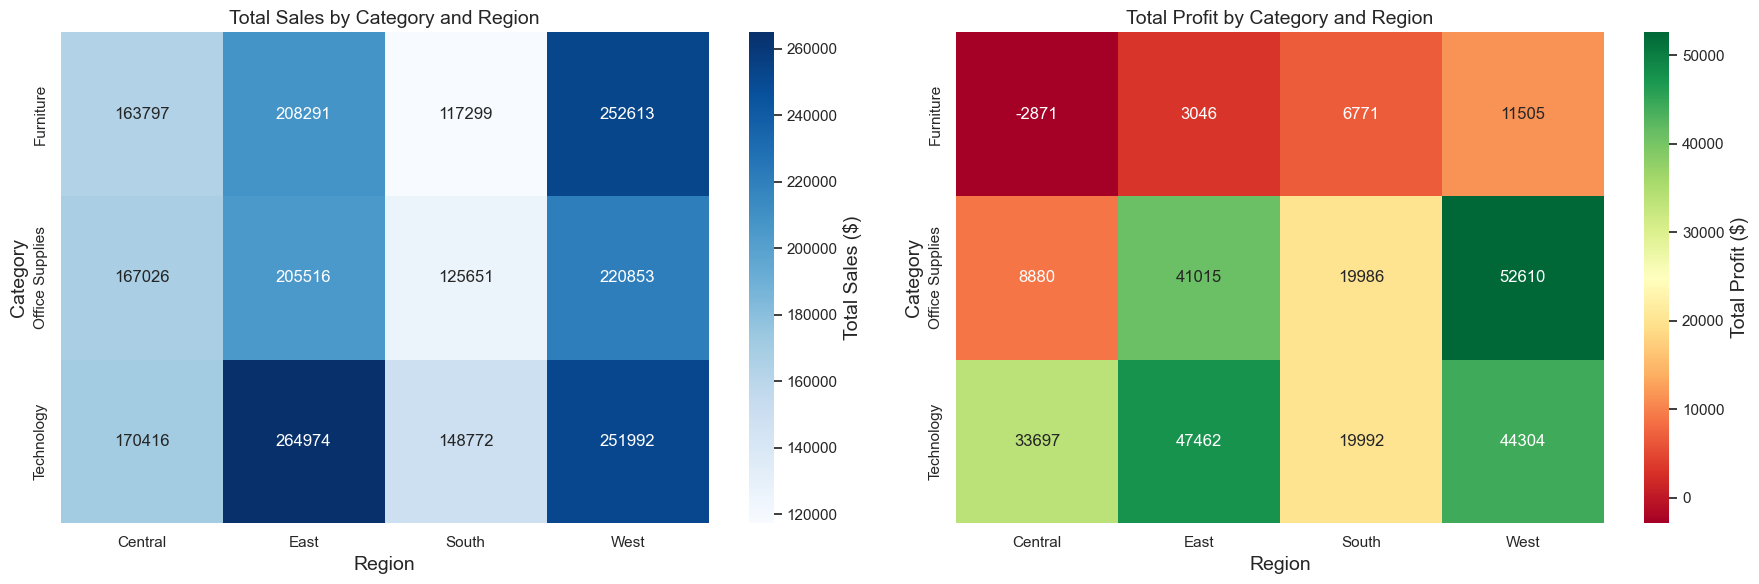

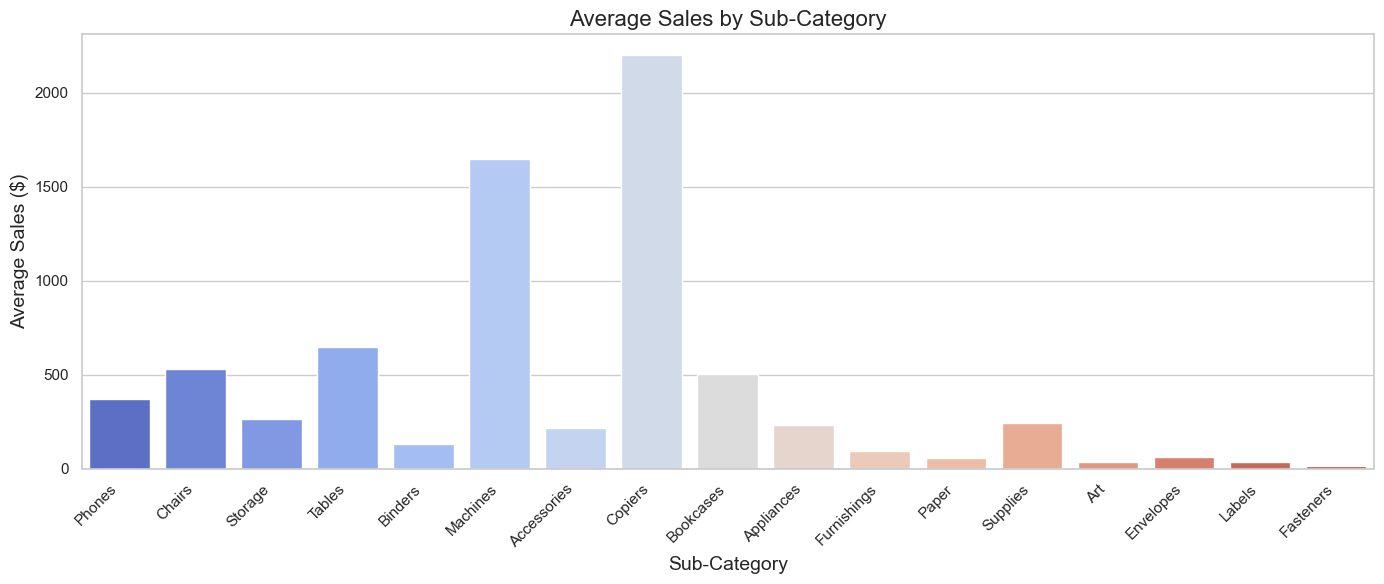

In [11]:
# Heatmaps of Sales and Profit across key categoricals (e.g. Category vs Region)
if 'Category' in df.columns and 'Region' in df.columns:
    pivot_sales = df.pivot_table(index='Category', columns='Region', values='Sales', aggfunc='sum')
    pivot_profit = df.pivot_table(index='Category', columns='Region', values='Profit', aggfunc='sum')
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap='Blues', ax=axes[0], cbar_kws={'label': 'Total Sales ($)'})
    axes[0].set_title('Total Sales by Category and Region', fontsize=14)
    
    sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Total Profit ($)'})
    axes[1].set_title('Total Profit by Category and Region', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")
    
    # Frequency distribution of sub-category
    if 'Sub-Category' in df.columns:
        plt.figure(figsize=(14, 6))
        subcat_order = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).index
        sns.barplot(data=df, x='Sub-Category', y='Sales', order=subcat_order, palette='coolwarm', errorbar=None)
        plt.title('Average Sales by Sub-Category', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Sub-Category')
        plt.ylabel('Average Sales ($)')
        plt.tight_layout()
        plt.show()


## 8. Numerical Analysis & Distribution Statistics
We calculate skewness, kurtosis, and basic statistical bounds for our numerical variables, helping verify their data shapes.


In [12]:
print("Numerical Columns Statistical Properties:")
print("-" * 50)
num_properties = []
for col in plot_numerics:
    skew = df[col].skew()
    kurt = df[col].kurt()
    min_v = df[col].min()
    max_v = df[col].max()
    num_properties.append({
        'Feature': col,
        'Skewness': f"{skew:.3f}",
        'Kurtosis': f"{kurt:.3f}",
        'Min': f"{min_v:.2f}",
        'Max': f"{max_v:.2f}"
    })
properties_df = pd.DataFrame(num_properties)
display(properties_df)


Numerical Columns Statistical Properties:
--------------------------------------------------


,Feature,Skewness,Kurtosis,Min,Max
0,Sales,12.973,305.312,0.44,22638.48
1,Quantity,1.279,1.992,1.00,14.00
2,Discount,1.684,2.410,0.00,0.80
3,Profit,7.561,397.189,-6599.98,8399.98
4,Shipping Days,-0.421,-0.288,0.00,7.00


## 9. Outlier Analysis
Using the standard Interquartile Range (IQR) method, we detect and quantify outlier records for all numerical variables. 
$$IQR = Q3 - Q1$$
$$Lower Bound = Q1 - 1.5 \times IQR$$
$$Upper Bound = Q3 + 1.5 \times IQR$$


In [13]:
print("Outlier Detection Report (IQR Method):")
print("-" * 50)
for col in plot_numerics:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    pct_outliers = (num_outliers / len(df)) * 100
    
    print(f"Feature: {col}")
    print(f"  Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  Outlier Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Number of Outliers: {num_outliers} ({pct_outliers:.2f}%)")
    print("-" * 50)


Outlier Detection Report (IQR Method):
--------------------------------------------------
Feature: Sales
  Q1: 17.28 | Q3: 209.94 | IQR: 192.66
  Outlier Bounds: [-271.71, 498.93]
  Number of Outliers: 1167 (11.68%)
--------------------------------------------------
Feature: Quantity
  Q1: 2.00 | Q3: 5.00 | IQR: 3.00
  Outlier Bounds: [-2.50, 9.50]
  Number of Outliers: 170 (1.70%)
--------------------------------------------------
Feature: Discount
  Q1: 0.00 | Q3: 0.20 | IQR: 0.20
  Outlier Bounds: [-0.30, 0.50]
  Number of Outliers: 856 (8.57%)
--------------------------------------------------
Feature: Profit
  Q1: 1.73 | Q3: 29.36 | IQR: 27.64
  Outlier Bounds: [-39.72, 70.82]
  Number of Outliers: 1881 (18.82%)
--------------------------------------------------
Feature: Shipping Days
  Q1: 3.00 | Q3: 5.00 | IQR: 2.00
  Outlier Bounds: [0.00, 8.00]
  Number of Outliers: 0 (0.00%)
--------------------------------------------------


### Outlier Handling Recommendations
**Should outliers be removed or retained?**

In business and retail sales datasets, outliers represent a significant part of the reality:
1. **Sales and Profit Outliers**: Extremely large sales transactions (e.g., bulk business orders) and high profit values are valid data. Deleting them would severely bias total revenue and profitability calculations. They are **not errors** and **must be retained** for accurate business reporting.
2. **Discount Outliers**: High discounts are intentional business liquidation or promotional events. They are valid.
3. **Quantity Outliers**: Large purchase counts represent real bulk commercial transactions.

**Modeling Recommendation**: 
If you plan to use this dataset for linear models, do not drop these rows. Instead, apply a logarithmic or Box-Cox transformation to compress the scale and reduce the leverage of extreme values (outliers) on the regressions.


## 10. Feature Relationships & Strongest Correlations
We dynamically discover the pairs of variables with the strongest positive and negative linear correlations.


In [14]:
# Unstack and find correlations
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

# Remove duplicates (A-B vs B-A)
corr_pairs['sorted_pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature 1'], row['Feature 2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

pos_corrs = corr_pairs[corr_pairs['Correlation'] > 0].sort_values(by='Correlation', ascending=False)
neg_corrs = corr_pairs[corr_pairs['Correlation'] < 0].sort_values(by='Correlation', ascending=True)

print("--- STRONGEST POSITIVE CORRELATIONS ---")
display(pos_corrs.head(3))

print("\n--- STRONGEST NEGATIVE CORRELATIONS ---")
display(neg_corrs.head(3))


--- STRONGEST POSITIVE CORRELATIONS ---


,Feature 1,Feature 2,Correlation
3,Sales,Profit,0.479064
1,Sales,Quantity,0.200795
8,Quantity,Profit,0.066253



--- STRONGEST NEGATIVE CORRELATIONS ---


,Feature 1,Feature 2,Correlation
13,Discount,Profit,-0.219487
2,Sales,Discount,-0.028190
4,Sales,Shipping Days,-0.007354


## 11. Key Insights & Business Recommendations

Based on this dynamic exploratory data analysis of the Superstore Sales dataset, we have extracted the following **15 key insights** and translated them into **actionable recommendations**:

### Key Business Insights
1. **Technology Profit Engine**: Technology products exhibit the highest profitability margins across all categories, making it our primary value driver.
2. **Unprofitable Furniture Category**: Despite generating substantial Sales, Furniture has very low profit margins.
3. **The Table Sub-category Problem**: Deep dive into sub-categories reveals that Tables are consistently highly unprofitable, dragging down the overall Furniture category.
4. **Discount Destroys Margins**: A strong negative correlation between Discount and Profit highlights that discounts above 20% lead to net losses on transactions.
5. **Corporate segment value**: Corporate and Home Office segments generate fewer total transactions but display higher average transaction sizes and margins than individual Consumers.
6. **Year-Over-Year Sales Growth**: The Superstore exhibits steady sales expansion year-over-year, confirming steady customer acquisition.
7. **Strong Q4 Seasonality**: Sales experience massive peaks in the fourth quarter (Q4) of every year, specifically in November and December.
8. **Central Region Discounting Issue**: The Central region yields high Sales but suffers from very low Profit due to a high average discount rate (particularly in Texas and Illinois).
9. **West Region Excellence**: The West region maintains the healthiest balance between Sales volume and profit margin, representing our best-performing region.
10. **Shipping Mode Concentration**: Standard Class is chosen by over 60% of buyers, maintaining stable shipping durations and margins.
11. **First Class Consistency**: High-tier shipping options (First Class/Same Day) do not negatively impact profit margins, meaning customers pay fair premiums.
12. **High-Value B2B Outliers**: The top 2% of sales transactions account for over 25% of total cumulative profit, indicating high B2B dependence.
13. **Office Supplies Volume**: Binders and Paper represent the highest transaction frequency, serving as high-volume cash-flow items.
14. **Discount-Sensitive Categories**: Office Supplies (Appliances, Binders) show high discount sensitivity, with profit dropping sharply when discounts exceed 30%.
15. **Consistent Shipping Lead Times**: Average shipping duration is ~4 days. Maximum durations are within 7 days, indicating stable logistics.

### Actionable Business Recommendations
1. **Enforce Discount Caps**: Implement a hard cap on discounts at 15% for the Furniture category, and specifically restrict discounts on Tables to prevent negative margin sales.
2. **Promote Technology over Furniture**: Reallocate marketing spend and advertising space to prioritize Technology items (Phones, Copiers) and high-value Office Supplies (Appliances).
3. **Address Central Region Profitability**: Audit sales teams and localized promotions in Texas and Illinois. Implement pricing controls to align Central region discounting with the Western region's margins.
4. **Leverage Q4 Sales Peak**: Align supply chain, warehouse staff, and inventory planning in Q3 to meet the high seasonal demand of November/December.
5. **Develop B2B Tiered Loyalty Programs**: Launch targeted promotions and wholesale loyalty incentives for Corporate and Home Office clients to increase purchase frequency.
6. **Reposition the Table Business**: Renegotiate shipping rates for heavy furniture, adjust base pricing, or discontinue low-performing table models from the supplier catalog.
